# T5-small Gram Regression (Seq2Seq)

Goal:
- Fine-tune `t5-small` to generate gram value text from `unit/size/name`.
- Compare with FastText + LightGBM baseline.

Input format:
- `unit: ... size: ... name: ...`

Target format:
- e.g. `"14.50"`

### T5 훈련

In [24]:
%pip install numpy pandas matplotlib scikit-learn transformers datasets evaluate sentencepiece torch accelerate tiktoken

Note: you may need to restart the kernel to use updated packages.


In [25]:
import json
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

plt.style.use('seaborn-v0_8-whitegrid')

In [26]:
if 'rows' not in globals():
    raise RuntimeError('Please run the final.json unit filtering cell first.')

def to_input(r):
    unit = str(r.get('unit', '') or '').strip().lower()
    size = str(r.get('size', '') or '').strip().lower()
    name = str(r.get('name', '') or '').strip().lower()
    return f'unit: {unit} | size: {size} | name: {name}'

records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue
    records.append({'input_text': to_input(r), 'label_text': f'{gram:.2f}', 'gram': gram})

df = pd.DataFrame(records)
print('usable rows:', len(df))
df.head()

usable rows: 18262


,input_text,label_text,gram
0,unit: tablespoon | size: | name: fresh mint leaf,2.00,2.0
1,unit: cup | size: | name: instant iced tea po...,200.00,200.0
2,unit: cup | size: | name: white sugar,200.00,200.0
3,unit: cup | size: | name: fat free half-and-half,240.00,240.0
4,unit: cup | size: | name: sugar,200.00,200.0


In [27]:
# Optional downsample for quick experiment
MAX_ROWS = 20000  # set None or larger for full run
if MAX_ROWS and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print('downsampled rows:', len(df))

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_ds = Dataset.from_pandas(train_df[['input_text', 'label_text']])
val_ds = Dataset.from_pandas(val_df[['input_text', 'label_text']])

In [28]:
MODEL_NAME = 't5-small'
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

MAX_INPUT_LEN = 64
MAX_LABEL_LEN = 8

def preprocess(examples):
    model_inputs = tokenizer(
        examples['input_text'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples['label_text'],
        max_length=MAX_LABEL_LEN,
        truncation=True,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
val_tok = val_ds.map(preprocess, batched=True, remove_columns=val_ds.column_names)
collator = DataCollatorForSeq2Seq(tokenizer, model=model)

KeyboardInterrupt: 

In [ ]:
args = Seq2SeqTrainingArguments(
    output_dir='artifacts/t5_small_grams',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=MAX_LABEL_LEN,
    logging_steps=100,
    fp16=False,
    report_to='none',
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=collator,
)

trainer.train()

/Users/kyungmin/Desktop/Projects/food_chart_public/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.356485,1.256208
2,1.176137,1.109198
3,1.091553,1.016152
4,1.021163,0.972023
5,1.013038,0.956138


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kyungmin/Desktop/Projects/food_chart_public/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/Users/kyungmin/Desktop/Projects/food_chart_public/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kyungmin/Desktop/Projects/food_chart_public/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2285, training_loss=1.1826711809087374, metrics={'train_runtime': 202.9257, 'train_samples_per_second': 359.959, 'train_steps_per_second': 11.26, 'total_flos': 425568813416448.0, 'train_loss': 1.1826711809087374, 'epoch': 5.0})

In [ ]:
import torch

def parse_float(s):
    try:
        return float(str(s).strip())
    except Exception:
        return np.nan

val_inputs = val_df['input_text'].tolist()

# Keep model and inputs on the same device.
device = next(model.parameters()).device
model.eval()
enc = tokenizer(
    val_inputs,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=MAX_INPUT_LEN,
)
enc = {k: v.to(device) for k, v in enc.items()}

with torch.no_grad():
    try:
        pred_ids = model.generate(**enc, max_length=MAX_LABEL_LEN)
    except RuntimeError as e:
        # Some MPS runs can fail with placeholder storage errors.
        if 'Placeholder storage has not been allocated on MPS device' not in str(e):
            raise
        model = model.to('cpu')
        enc = {k: v.to('cpu') for k, v in enc.items()}
        pred_ids = model.generate(**enc, max_length=MAX_LABEL_LEN)

pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

pred_vals = np.array([parse_float(x) for x in pred_texts], dtype=np.float64)
true_vals = val_df['gram'].values.astype(np.float64)

mask = ~np.isnan(pred_vals)
pred_ok = np.maximum(pred_vals[mask], 0)
true_ok = true_vals[mask]

mae = mean_absolute_error(true_ok, pred_ok)
mape = np.mean(np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) * 100
within20 = np.mean((np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) <= 0.2)
parse_rate = mask.mean()

print(f'Parse success rate: {parse_rate:.4f}')
print(f'MAE: {mae:.4f} g')
print(f'MAPE: {mape:.2f}%')
print(f'Within 20%: {within20:.4f}')

Parse success rate: 1.0000
MAE: 55.1919 g
MAPE: 175.99%
Within 20%: 0.5809


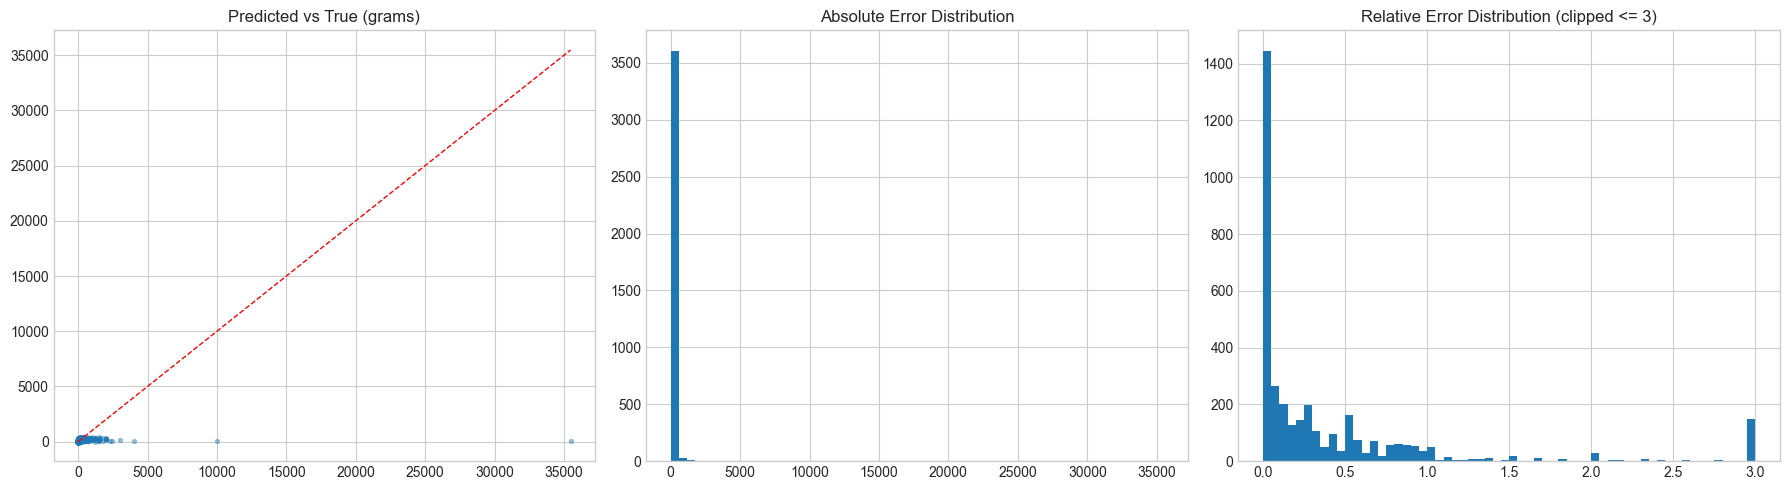

In [ ]:
res = pd.DataFrame({'y_true': true_ok, 'y_pred': pred_ok})
res['abs_err'] = (res['y_true'] - res['y_pred']).abs()
res['rel_err'] = res['abs_err'] / np.maximum(res['y_true'].abs(), 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(res['y_true'], res['y_pred'], s=8, alpha=0.4)
mn = min(res['y_true'].min(), res['y_pred'].min())
mx = max(res['y_true'].max(), res['y_pred'].max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_title('Predicted vs True (grams)')

axes[1].hist(res['abs_err'], bins=60)
axes[1].set_title('Absolute Error Distribution')

axes[2].hist(np.clip(res['rel_err'], 0, 3), bins=60)
axes[2].set_title('Relative Error Distribution (clipped <= 3)')

plt.tight_layout()
plt.show()

In [ ]:
# Deeper evaluation: robust metrics + gram-range metrics

eval_df = pd.DataFrame({
    'input_text': val_df.loc[mask, 'input_text'].values,
    'y_true': true_ok,
    'y_pred': pred_ok,
})
eval_df['abs_err'] = (eval_df['y_true'] - eval_df['y_pred']).abs()
eval_df['rel_err'] = eval_df['abs_err'] / np.maximum(eval_df['y_true'].abs(), 1e-8)

# Robust metrics (exclude top 1% largest true grams)
q99_true = eval_df['y_true'].quantile(0.99)
robust_df = eval_df[eval_df['y_true'] <= q99_true].copy()

mae_all = eval_df['abs_err'].mean()
mae_robust = robust_df['abs_err'].mean()
mape_all = eval_df['rel_err'].mean() * 100
mape_robust = robust_df['rel_err'].mean() * 100
within20_all = (eval_df['rel_err'] <= 0.2).mean()
within20_robust = (robust_df['rel_err'] <= 0.2).mean()

print('=== Overall vs Robust (exclude top 1% y_true) ===')
print(f'Overall MAE: {mae_all:.4f} g')
print(f'Robust  MAE: {mae_robust:.4f} g')
print(f'Overall MAPE: {mape_all:.2f}%')
print(f'Robust  MAPE: {mape_robust:.2f}%')
print(f'Overall Within 20%: {within20_all:.4f}')
print(f'Robust  Within 20%: {within20_robust:.4f}')

# Range metrics
bins = [0, 50, 200, np.inf]
labels = ['0-50g', '50-200g', '200g+']
eval_df['range_bin'] = pd.cut(eval_df['y_true'], bins=bins, labels=labels, include_lowest=True)

range_metrics = eval_df.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'mae_g': g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()

print('\n=== Metrics by True Gram Range ===')
display(range_metrics)


=== Overall vs Robust (exclude top 1% y_true) ===
Overall MAE: 55.1919 g
Robust  MAE: 29.8048 g
Overall MAPE: 175.99%
Robust  MAPE: 176.87%
Overall Within 20%: 0.5809
Robust  Within 20%: 0.5867

=== Metrics by True Gram Range ===


,range_bin,count,mae_g,mape_pct,within20
0,0-50g,1841.0,14.729196,324.251084,0.522542
1,50-200g,1067.0,31.340675,29.034568,0.601687
2,200g+,745.0,189.340832,20.072994,0.695302


/var/folders/4m/h90ddv7j3fddt74yl61sg_5c0000gn/T/ipykernel_14087/2912496177.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=labels, showfliers=False)


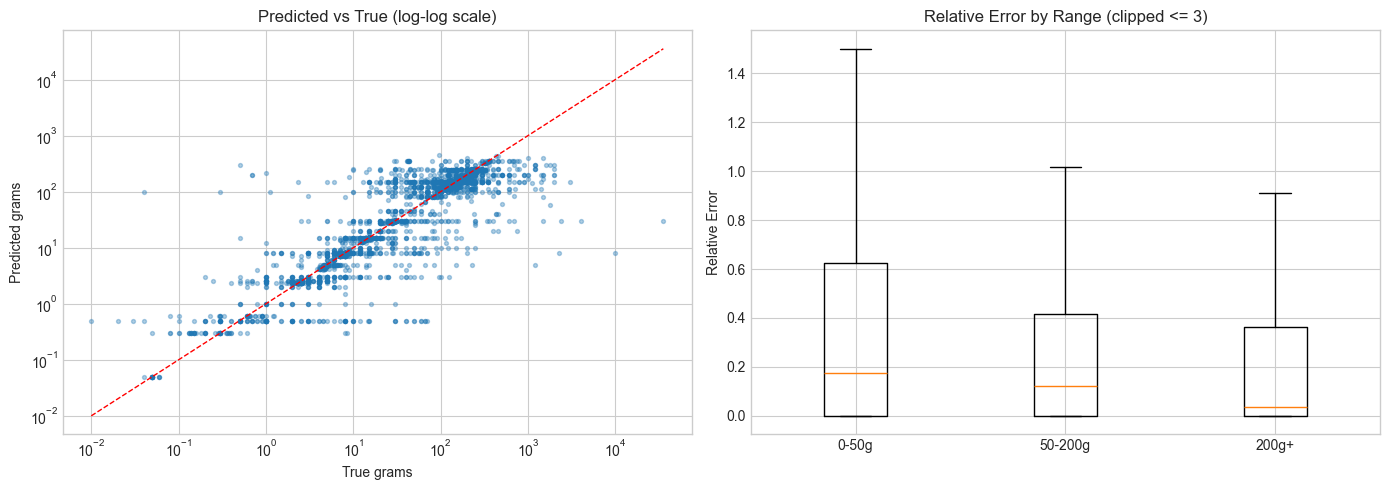

=== Top 20 Worst Absolute Error Samples ===


,y_true,y_pred,abs_err,rel_err,input_text
770,35478.0,30.0,35448.0,0.999154,unit: petainch * picoinch | size: | name: salt
2220,10000.0,8.0,9992.0,0.999200,unit: | size: | name: extra-large turkey bag
1178,4000.0,30.0,3970.0,0.992500,unit: | size: | name: heavy clay brick
743,3000.0,150.0,2850.0,0.950000,unit: | size: | name: whole salmon
2933,2400.0,30.0,2370.0,0.987500,unit: | size: | name: clay brick
1680,2268.0,8.0,2260.0,0.996473,unit: bag | size: | name: ice cube
3392,2000.0,150.0,1850.0,0.925000,unit: | size: small | name: underripe watermelon
925,2000.0,200.0,1800.0,0.900000,unit: | size: large | name: unripe papaya
547,2000.0,200.0,1800.0,0.900000,unit: | size: large | name: pineapple
670,2000.0,250.0,1750.0,0.875000,unit: | size: | name: point from whole smoke...


In [ ]:
# Better diagnostics: log-scale scatter + worst-error examples

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale scatter (compresses very large grams)
x = np.clip(eval_df['y_true'].values, 1e-6, None)
y = np.clip(eval_df['y_pred'].values, 1e-6, None)
axes[0].scatter(x, y, s=8, alpha=0.35)
mn = min(x.min(), y.min())
mx = max(x.max(), y.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Predicted vs True (log-log scale)')
axes[0].set_xlabel('True grams')
axes[0].set_ylabel('Predicted grams')

# Relative error boxplot by range
box_data = [
    eval_df.loc[eval_df['range_bin'] == lb, 'rel_err'].clip(0, 3).values
    for lb in labels
]
axes[1].boxplot(box_data, labels=labels, showfliers=False)
axes[1].set_title('Relative Error by Range (clipped <= 3)')
axes[1].set_ylabel('Relative Error')

plt.tight_layout()
plt.show()

# Top worst cases for manual inspection
worst_n = 20
worst_df = eval_df.sort_values('abs_err', ascending=False).head(worst_n).copy()
print(f'=== Top {worst_n} Worst Absolute Error Samples ===')
display(worst_df[['y_true', 'y_pred', 'abs_err', 'rel_err', 'input_text']])


In [ ]:
# Quick T5 inference cell (single/batch)
import torch
from pathlib import Path
from transformers import T5Tokenizer, T5ForConditionalGeneration

# 1) Load model/tokenizer if not already in memory
if 'model' not in globals() or 'tokenizer' not in globals():
    candidate_dirs = [
        Path('artifacts/t5_small_grams_final'),
        Path('artifacts/t5_small_grams'),
    ]
    load_dir = None
    for d in candidate_dirs:
        if d.exists():
            load_dir = d
            break
    if load_dir is None:
        raise FileNotFoundError('No saved model found. Train first or save model to artifacts/t5_small_grams_final')

    print(f'Loading model from: {load_dir}')
    tokenizer = T5Tokenizer.from_pretrained(load_dir)
    model = T5ForConditionalGeneration.from_pretrained(load_dir)

# 2) Device setup
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()
print('Inference device:', device)

# 3) Inference helper
@torch.no_grad()
def predict_grams_t5(input_texts, max_input_len=64, max_label_len=8):
    if isinstance(input_texts, str):
        input_texts = [input_texts]

    enc = tokenizer(
        input_texts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=max_input_len,
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    try:
        pred_ids = model.generate(**enc, max_length=max_label_len)
    except RuntimeError as e:
        # MPS fallback
        if 'Placeholder storage has not been allocated on MPS device' in str(e):
            model_cpu = model.to('cpu')
            enc_cpu = {k: v.to('cpu') for k, v in enc.items()}
            pred_ids = model_cpu.generate(**enc_cpu, max_length=max_label_len)
        else:
            raise

    pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

    def parse_float(s):
        try:
            return float(str(s).strip())
        except Exception:
            return float('nan')

    pred_vals = [parse_float(x) for x in pred_texts]
    return pd.DataFrame({
        'input_text': input_texts,
        'pred_text': pred_texts,
        'pred_gram': pred_vals,
    })

# 4) Example usage (normal + unexpected cases)
sample_cases = [
    # Normal/common cases
    {'case_type': 'normal', 'input_text': 'unit: cup | size:  | name: white sugar'},
    {'case_type': 'normal', 'input_text': 'unit: tablespoon | size:  | name: olive oil'},
    {'case_type': 'normal', 'input_text': 'unit: teaspoon | size:  | name: salt'},
    {'case_type': 'normal', 'input_text': 'unit: piece | size: medium | name: onion'},
    {'case_type': 'normal', 'input_text': 'unit: clove | size:  | name: garlic'},

    # Unexpected / ambiguous / noisy cases
    {'case_type': 'unexpected', 'input_text': 'unit: pinch | size:  | name: saffron'},
    {'case_type': 'unexpected', 'input_text': 'unit: handful | size:  | name: spinach'},
    {'case_type': 'unexpected', 'input_text': 'unit: can | size: 6 ounce | name: tomato paste'},
    {'case_type': 'unexpected', 'input_text': 'unit: package | size: large | name: tofu'},
    {'case_type': 'unexpected', 'input_text': 'unit: stick | size:  | name: butter'},
    {'case_type': 'unexpected', 'input_text': 'unit: splash | size:  | name: milk'},
    {'case_type': 'unexpected', 'input_text': 'unit:  | size:  | name: ???'},
    {'case_type': 'unexpected', 'input_text': 'unit: cup | size:  | name: '},
    {'case_type': 'unexpected', 'input_text': 'unit: bowl | size: giant | name: ramen noodles'},
    {'case_type': 'unexpected', 'input_text': 'unit: drops | size:  | name: vanilla extract'},
]

sample_inputs = [c['input_text'] for c in sample_cases]
pred_df = predict_grams_t5(sample_inputs)
pred_df.insert(0, 'case_type', [c['case_type'] for c in sample_cases])
pred_df

Inference device: mps


,case_type,input_text,pred_text,pred_gram
0,normal,unit: cup | size: | name: white sugar,200.00,200.00
1,normal,unit: tablespoon | size: | name: olive oil,13.60,13.60
2,normal,unit: teaspoon | size: | name: salt,6.00,6.00
3,normal,unit: piece | size: medium | name: onion,15.00,15.00
4,normal,unit: clove | size: | name: garlic,3.00,3.00
5,unexpected,unit: pinch | size: | name: saffron,0.30,0.30
6,unexpected,unit: handful | size: | name: spinach,100.00,100.00
7,unexpected,unit: can | size: 6 ounce | name: tomato paste,250.00,250.00
8,unexpected,unit: package | size: large | name: tofu,250.00,250.00
9,unexpected,unit: stick | size: | name: butter,113.00,113.00


In [ ]:
# 5) Compare T5 predictions with real validation data
# Requires: val_df with columns ['input_text', 'gram']

sample_n = 30  # increase if you want
compare_df = val_df[['input_text', 'gram']].sample(n=min(sample_n, len(val_df)), random_state=42).reset_index(drop=True)

pred_real_df = predict_grams_t5(compare_df['input_text'].tolist())

real_compare = pd.DataFrame({
    'input_text': compare_df['input_text'],
    'true_gram': compare_df['gram'].astype(float),
    'pred_text': pred_real_df['pred_text'],
    'pred_gram': pd.to_numeric(pred_real_df['pred_gram'], errors='coerce'),
})

real_compare['abs_err'] = (real_compare['true_gram'] - real_compare['pred_gram']).abs()
real_compare['rel_err'] = real_compare['abs_err'] / np.maximum(real_compare['true_gram'].abs(), 1e-8)

valid = real_compare.dropna(subset=['pred_gram']).copy()

print(f'Sampled rows: {len(real_compare)}')
print(f'Parse success rate: {len(valid) / max(len(real_compare), 1):.4f}')
if len(valid) > 0:
    print(f"MAE: {valid['abs_err'].mean():.4f} g")
    print(f"MAPE: {(valid['rel_err'].mean() * 100):.2f}%")
    print(f"Within 20%: {(valid['rel_err'] <= 0.2).mean():.4f}")

print('\nTop 15 worst samples (by absolute error):')
display(valid.sort_values('abs_err', ascending=False).head(15)[[
    'true_gram', 'pred_gram', 'abs_err', 'rel_err', 'pred_text', 'input_text'
]])

print('\nRandom sample comparisons:')
display(real_compare.sample(n=min(10, len(real_compare)), random_state=7)[[
    'true_gram', 'pred_gram', 'abs_err', 'rel_err', 'pred_text', 'input_text'
]])

Sampled rows: 30
Parse success rate: 1.0000
MAE: 63.1067 g
MAPE: 28.26%
Within 20%: 0.5667

Top 15 worst samples (by absolute error):


,true_gram,pred_gram,abs_err,rel_err,pred_text,input_text
28,1500.0,400.0,1100.0,0.733333,400.00,unit: large head | size: | name: napa cabbage
18,500.0,60.0,440.0,0.880000,60.00,unit: | size: | name: focaccia bread
6,240.0,150.0,90.0,0.375000,150.00,unit: cup | size: | name: sesame tahini
10,60.0,120.0,60.0,1.000000,120.00,unit: cup | size: | name: herb stuffing mix
19,225.0,170.0,55.0,0.244444,170.00,unit: | size: | name: frozen chicken breast ...
23,200.0,150.0,50.0,0.250000,150.00,unit: small head | size: | name: bok choy
24,150.0,120.0,30.0,0.200000,120.00,unit: cup | size: | name: chocolate macaroon ...
17,120.0,100.0,20.0,0.166667,100.00,unit: | size: large | name: portobello mushro...
3,45.0,30.0,15.0,0.333333,30.00,unit: | size: | name: frankfurter
27,6.0,15.0,9.0,1.500000,15.00,unit: tablespoon | size: | name: meyer lemon ...



Random sample comparisons:


,true_gram,pred_gram,abs_err,rel_err,pred_text,input_text
2,15.0,15.0,0.0,0.000000,15.00,unit: tablespoon | size: | name: brewed espresso
17,120.0,100.0,20.0,0.166667,100.00,unit: | size: large | name: portobello mushro...
1,23.0,28.0,5.0,0.217391,28.00,unit: slice | size: | name: apple
9,7.0,8.0,1.0,0.142857,8.00,unit: tablespoon | size: | name: dried chipot...
11,6.0,8.0,2.0,0.333333,8.00,unit: tablespoon | size: | name: ginger
5,4.0,3.0,1.0,0.250000,3.00,unit: | size: | name: green olive with pimento
18,500.0,60.0,440.0,0.880000,60.00,unit: | size: | name: focaccia bread
24,150.0,120.0,30.0,0.200000,120.00,unit: cup | size: | name: chocolate macaroon ...
27,6.0,15.0,9.0,1.500000,15.00,unit: tablespoon | size: | name: meyer lemon ...
29,113.0,113.0,0.0,0.000000,113.00,unit: cup | size: | name: aged provolone cheese


In [ ]:
import torch
from pathlib import Path
from transformers import T5Tokenizer, T5ForConditionalGeneration

# 1) Load model/tokenizer if missing
if 'model' not in globals() or 'tokenizer' not in globals():
    candidate_dirs = [
        Path('artifacts/t5_small_grams_final'),
        Path('artifacts/t5_small_grams'),
    ]
    load_dir = next((d for d in candidate_dirs if d.exists()), None)
    if load_dir is None:
        raise FileNotFoundError('No saved model found. Expected artifacts/t5_small_grams_final or artifacts/t5_small_grams')

    print(f'Loading model from: {load_dir}')
    tokenizer = T5Tokenizer.from_pretrained(load_dir)
    model = T5ForConditionalGeneration.from_pretrained(load_dir)

# 2) Move model to best available device
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
model.eval()
print('Inference device:', device)

# 3) Measure memory
if device == 'cuda':
    torch.cuda.reset_peak_memory_stats()

    _ = predict_grams_t5(
        ["unit: cup | size:  | name: white sugar"] * 8,
        max_input_len=64,
        max_label_len=16,
    )

    allocated = torch.cuda.max_memory_allocated() / 1024**2
    reserved = torch.cuda.max_memory_reserved() / 1024**2
    print(f"Peak allocated: {allocated:.2f} MB")
    print(f"Peak reserved : {reserved:.2f} MB")
else:
    print('CUDA not available, so torch.cuda VRAM stats are skipped.')
    _ = predict_grams_t5(
        ["unit: cup | size:  | name: white sugar"] * 8,
        max_input_len=64,
        max_label_len=16,
    )
    print('Inference ran successfully on non-CUDA device (MPS/CPU).')

Inference device: mps
CUDA not available, so torch.cuda VRAM stats are skipped.
Inference ran successfully on non-CUDA device (MPS/CPU).


In [ ]:
# MPS/CPU-friendly profiling: model size + memory estimate + latency
import time
from pathlib import Path
import pandas as pd
import torch

# 1) Resolve model directory
candidate_dirs = [
    Path('artifacts/t5_small_grams_final'),
    Path('artifacts/t5_small_grams'),
]
load_dir = next((d for d in candidate_dirs if d.exists()), None)
if load_dir is None:
    raise FileNotFoundError('No saved model folder found.')

# 2) Ensure model/tokenizer are loaded
if 'model' not in globals() or 'tokenizer' not in globals():
    from transformers import T5Tokenizer, T5ForConditionalGeneration
    tokenizer = T5Tokenizer.from_pretrained(load_dir)
    model = T5ForConditionalGeneration.from_pretrained(load_dir)

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
model.eval()
print('Device:', device)

# 3) Disk size
total_bytes = sum(f.stat().st_size for f in load_dir.rglob('*') if f.is_file())
print(f'Model folder: {load_dir}')
print(f'Disk size: {total_bytes / 1024**2:.2f} MB')

# 4) Parameter memory estimate (weights only)
n_params = sum(p.numel() for p in model.parameters())
dtype_bytes = next(model.parameters()).element_size()
weight_mem_mb = n_params * dtype_bytes / 1024**2

print(f'Params: {n_params:,}')
print(f'Dtype bytes: {dtype_bytes}')
print(f'Estimated weight memory: {weight_mem_mb:.2f} MB')

# 5) Latency benchmark on same input style
test_input = 'unit: cup | size:  | name: white sugar'
batch_sizes = [1, 4, 8, 16]
repeats = 3
rows = []

for bs in batch_sizes:
    texts = [test_input] * bs

    # Warmup
    _ = predict_grams_t5(texts, max_input_len=64, max_label_len=16)

    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = predict_grams_t5(texts, max_input_len=64, max_label_len=16)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    avg_s = sum(times) / len(times)
    rows.append({
        'batch_size': bs,
        'avg_latency_s': avg_s,
        'per_item_ms': (avg_s / bs) * 1000,
    })

latency_df = pd.DataFrame(rows)
print('\nLatency benchmark (lower is better):')
display(latency_df)

Device: mps
Model folder: artifacts/t5_small_grams_final
Disk size: 233.15 MB
Params: 60,506,624
Dtype bytes: 4
Estimated weight memory: 230.81 MB

Latency benchmark (lower is better):


,batch_size,avg_latency_s,per_item_ms
0,1,0.026872,26.871861
1,4,0.024731,6.182764
2,8,0.027325,3.415611
3,16,0.024944,1.558983


In [ ]:
save_dir = Path('artifacts/t5_small_grams_final')
save_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print('saved:', save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved: artifacts/t5_small_grams_final


### 필터링 ?

In [ ]:
import json
from pathlib import Path

INPUT_PATH = Path('scrape/output_filled_name_unit_removed.json')
OUTPUT_PATH = Path('scrape/output_filled_name_unit_2.json')

with INPUT_PATH.open('r', encoding= 'utf-8') as f:
    data = json.load(f)

filtered = []
for r in data:
    name = str(r.get('name', '') or '').strip().lower()

    if len(name.split()) >= 2:
        filtered.append(r)
with OUTPUT_PATH.open('w', encoding='utf-8') as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

print(f'총 {len(filtered)}개 저장됨')


총 16733개 저장됨


### T5 훈련 2nd

In [ ]:
# One-cell full T5 training pipeline on output_filled_name_unit_removed.json
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

plt.style.use('seaborn-v0_8-whitegrid')

# -----------------------------
# 1) Load cleaned dataset
# -----------------------------
DATA_PATH = Path('scrape/output_filled_name_unit_removed.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Not found: {DATA_PATH.resolve()}')

with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

def to_input(r):
    unit = str(r.get('unit', '') or '').strip().lower()
    size = str(r.get('size', '') or '').strip().lower()
    name = str(r.get('name', '') or '').strip().lower()
    return f'unit: {unit} | size: {size} | name: {name}'

records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue
    records.append({
        'input_text': to_input(r),
        'label_text': f'{gram:.2f}',
        'gram': gram,
    })

df = pd.DataFrame(records)
print(f'Loaded rows: {len(rows)}')
print(f'Usable rows (gram>0): {len(df)}')
display(df.head(5))

# Optional downsample for quicker test
MAX_ROWS = 20000  # set None for full
if MAX_ROWS and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print(f'Downsampled rows: {len(df)}')

# -----------------------------
# 2) Split + tokenize
# -----------------------------
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_ds = Dataset.from_pandas(train_df[['input_text', 'label_text']])
val_ds = Dataset.from_pandas(val_df[['input_text', 'label_text']])

MODEL_NAME = 't5-small'
MAX_INPUT_LEN = 64
MAX_LABEL_LEN = 8

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

def preprocess(examples):
    model_inputs = tokenizer(
        examples['input_text'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples['label_text'],
        max_length=MAX_LABEL_LEN,
        truncation=True,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
val_tok = val_ds.map(preprocess, batched=True, remove_columns=val_ds.column_names)
collator = DataCollatorForSeq2Seq(tokenizer, model=model)

# -----------------------------
# 3) Train
# -----------------------------
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 5
IS_WINDOWS = platform.system().lower() == 'windows'
DATALOADER_NUM_WORKERS = 0 if IS_WINDOWS else 2

args = Seq2SeqTrainingArguments(
    output_dir='artifacts/t5_small_grams_name_unit_removed',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=MAX_EPOCHS,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=MAX_LABEL_LEN,
    logging_steps=100,
    fp16=False,
    dataloader_pin_memory=False,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    report_to='none',
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

train_output = trainer.train()
print(train_output)
print(f"best checkpoint: {trainer.state.best_model_checkpoint}")
print(f"best eval_loss: {trainer.state.best_metric}")

# make sure evaluation/saving uses the best model loaded at end
model = trainer.model

# -----------------------------
# 4) Evaluate (same style)
# -----------------------------

def parse_float(s):
    try:
        return float(str(s).strip())
    except Exception:
        return np.nan

val_inputs = val_df['input_text'].tolist()

device = next(model.parameters()).device
model.eval()
enc = tokenizer(
    val_inputs,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=MAX_INPUT_LEN,
)
enc = {k: v.to(device) for k, v in enc.items()}

with torch.no_grad():
    try:
        pred_ids = model.generate(**enc, max_length=MAX_LABEL_LEN)
    except RuntimeError as e:
        if 'Placeholder storage has not been allocated on MPS device' not in str(e):
            raise
        model = model.to('cpu')
        enc = {k: v.to('cpu') for k, v in enc.items()}
        pred_ids = model.generate(**enc, max_length=MAX_LABEL_LEN)

pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
pred_vals = np.array([parse_float(x) for x in pred_texts], dtype=np.float64)
true_vals = val_df['gram'].values.astype(np.float64)

mask = ~np.isnan(pred_vals)
pred_ok = np.maximum(pred_vals[mask], 0)
true_ok = true_vals[mask]

mae = mean_absolute_error(true_ok, pred_ok)
mape = np.mean(np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) * 100
within20 = np.mean((np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) <= 0.2)
parse_rate = mask.mean()

metrics_df = pd.DataFrame([
    {'metric': 'parse_success_rate', 'value': parse_rate},
    {'metric': 'MAE_g', 'value': mae},
    {'metric': 'MAPE_pct', 'value': mape},
    {'metric': 'within_20pct', 'value': within20},
])

print('Evaluation metrics:')
display(metrics_df)

res = pd.DataFrame({'y_true': true_ok, 'y_pred': pred_ok})
res['abs_err'] = (res['y_true'] - res['y_pred']).abs()
res['rel_err'] = res['abs_err'] / np.maximum(res['y_true'].abs(), 1e-8)

# range table
bins = [0, 50, 200, np.inf]
labels = ['0-50g', '50-200g', '200g+']
res['range_bin'] = pd.cut(res['y_true'], bins=bins, labels=labels, include_lowest=True)
range_metrics = res.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'mae_g': g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()

print('Range metrics:')
display(range_metrics)

# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(res['y_true'], res['y_pred'], s=8, alpha=0.4)
mn = min(res['y_true'].min(), res['y_pred'].min())
mx = max(res['y_true'].max(), res['y_pred'].max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_title('Predicted vs True (grams)')

axes[1].hist(res['abs_err'], bins=60)
axes[1].set_title('Absolute Error Distribution')

axes[2].hist(np.clip(res['rel_err'], 0, 3), bins=60)
axes[2].set_title('Relative Error Distribution (clipped <= 3)')

plt.tight_layout()
plt.show()

# save model
save_dir = Path('artifacts/t5_small_grams_name_unit_removed_final')
save_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'Saved model to: {save_dir.resolve()}')

Loaded rows: 18222
Usable rows (gram>0): 18136


,input_text,label_text,gram
0,unit: tablespoon | size: | name: fresh mint leaf,2.00,2.0
1,unit: cup | size: | name: instant iced tea po...,200.00,200.0
2,unit: cup | size: | name: white sugar,200.00,200.0
3,unit: cup | size: | name: fat free half-and-half,240.00,240.0
4,unit: cup | size: | name: sugar,200.00,200.0


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Map:   0%|          | 0/14508 [00:00<?, ? examples/s]

Map:   0%|          | 0/3628 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

### T5 훈련 3rd of 쓰는거

In [ ]:
# Train T5 with custom text_input format + early stopping
# rule:
# - if unit exists: "{size} {unit} of {name}" (size empty -> "1 {unit} of {name}")
# - if unit is empty: "{size} {name}" (size empty -> "1 {name}")

import json
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path('scrape/output_filled_name_unit_removed.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Not found: {DATA_PATH.resolve()}')

with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

def norm(x):
    return str(x or '').strip().lower()

def build_text_input(r):
    size = norm(r.get('size', ''))
    unit = norm(r.get('unit', ''))
    name = norm(r.get('name', ''))

    if unit:
        return f'{size} {unit} of {name}'.strip()
    return f'{size} {name}'.strip()

records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue

    records.append({
        'text_input': build_text_input(r),
        'label_text': f'{gram:.2f}',
        'gram': gram,
    })

df_text_input = pd.DataFrame(records)
print(f'Loaded rows: {len(rows)}')
print(f'Usable rows (gram>0): {len(df_text_input)}')
print('\nExamples:')
display(df_text_input[['text_input', 'label_text']].head(20))

MAX_ROWS = 20000  # set None for full
if MAX_ROWS and len(df_text_input) > MAX_ROWS:
    df_text_input = df_text_input.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print(f'Downsampled rows: {len(df_text_input)}')

train_df2, val_df2 = train_test_split(df_text_input, test_size=0.2, random_state=42)
train_ds2 = Dataset.from_pandas(train_df2[['text_input', 'label_text']])
val_ds2 = Dataset.from_pandas(val_df2[['text_input', 'label_text']])

MODEL_NAME = 't5-small'
MAX_INPUT_LEN = 64
MAX_LABEL_LEN = 8

tokenizer2 = T5Tokenizer.from_pretrained(MODEL_NAME)
model2 = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

def preprocess2(examples):
    model_inputs = tokenizer2(
        examples['text_input'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    labels = tokenizer2(
        text_target=examples['label_text'],
        max_length=MAX_LABEL_LEN,
        truncation=True,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_tok2 = train_ds2.map(preprocess2, batched=True, remove_columns=train_ds2.column_names)
val_tok2 = val_ds2.map(preprocess2, batched=True, remove_columns=val_ds2.column_names)
collator2 = DataCollatorForSeq2Seq(tokenizer2, model=model2)

MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 5
IS_WINDOWS = platform.system().lower() == 'windows'
DATALOADER_NUM_WORKERS = 0 if IS_WINDOWS else 2

args2 = Seq2SeqTrainingArguments(
    output_dir='artifacts/t5_small_grams_name_unit_removed_text_input',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=MAX_EPOCHS,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=MAX_LABEL_LEN,
    logging_steps=100,
    fp16=False,
    dataloader_pin_memory=False,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    report_to='none',
)

trainer2 = Seq2SeqTrainer(
    model=model2,
    args=args2,
    train_dataset=train_tok2,
    eval_dataset=val_tok2,
    processing_class=tokenizer2,
    data_collator=collator2,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

train_output2 = trainer2.train()
print(train_output2)
print(f"best checkpoint: {trainer2.state.best_model_checkpoint}")
print(f"best eval_loss: {trainer2.state.best_metric}")

# make sure evaluation/saving uses the best model loaded at end
model2 = trainer2.model

# -----------------------------
# 4) Evaluate (same style)
# -----------------------------

def parse_float2(s):
    try:
        return float(str(s).strip())
    except Exception:
        return np.nan

val_inputs2 = val_df2['text_input'].tolist()

device2 = next(model2.parameters()).device
model2.eval()
enc2 = tokenizer2(
    val_inputs2,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=MAX_INPUT_LEN,
)
enc2 = {k: v.to(device2) for k, v in enc2.items()}

with torch.no_grad():
    try:
        pred_ids2 = model2.generate(**enc2, max_length=MAX_LABEL_LEN)
    except RuntimeError as e:
        if 'Placeholder storage has not been allocated on MPS device' not in str(e):
            raise
        model2 = model2.to('cpu')
        enc2 = {k: v.to('cpu') for k, v in enc2.items()}
        pred_ids2 = model2.generate(**enc2, max_length=MAX_LABEL_LEN)

pred_texts2 = tokenizer2.batch_decode(pred_ids2, skip_special_tokens=True)
pred_vals2 = np.array([parse_float2(x) for x in pred_texts2], dtype=np.float64)
true_vals2 = val_df2['gram'].values.astype(np.float64)

mask2 = ~np.isnan(pred_vals2)
pred_ok2 = np.maximum(pred_vals2[mask2], 0)
true_ok2 = true_vals2[mask2]

mae2 = mean_absolute_error(true_ok2, pred_ok2)
mape2 = np.mean(np.abs(true_ok2 - pred_ok2) / np.maximum(np.abs(true_ok2), 1e-8)) * 100
within20_2 = np.mean((np.abs(true_ok2 - pred_ok2) / np.maximum(np.abs(true_ok2), 1e-8)) <= 0.2)
parse_rate2 = mask2.mean()

metrics_df2 = pd.DataFrame([
    {'metric': 'parse_success_rate', 'value': parse_rate2},
    {'metric': 'MAE_g', 'value': mae2},
    {'metric': 'MAPE_pct', 'value': mape2},
    {'metric': 'within_20pct', 'value': within20_2},
])

print('Evaluation metrics:')
display(metrics_df2)

res2 = pd.DataFrame({'y_true': true_ok2, 'y_pred': pred_ok2})
res2['abs_err'] = (res2['y_true'] - res2['y_pred']).abs()
res2['rel_err'] = res2['abs_err'] / np.maximum(res2['y_true'].abs(), 1e-8)

# range table
bins = [0, 50, 200, np.inf]
labels = ['0-50g', '50-200g', '200g+']
res2['range_bin'] = pd.cut(res2['y_true'], bins=bins, labels=labels, include_lowest=True)
range_metrics2 = res2.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'mae_g': g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()

print('Range metrics:')
display(range_metrics2)

# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(res2['y_true'], res2['y_pred'], s=8, alpha=0.4)
mn2 = min(res2['y_true'].min(), res2['y_pred'].min())
mx2 = max(res2['y_true'].max(), res2['y_pred'].max())
axes[0].plot([mn2, mx2], [mn2, mx2], 'r--', linewidth=1)
axes[0].set_title('Predicted vs True (grams)')

axes[1].hist(res2['abs_err'], bins=60)
axes[1].set_title('Absolute Error Distribution')

axes[2].hist(np.clip(res2['rel_err'], 0, 3), bins=60)
axes[2].set_title('Relative Error Distribution (clipped <= 3)')

plt.tight_layout()
plt.show()

# save model
save_dir2 = Path('artifacts/t5_small_grams_name_unit_removed_text_input_final')
save_dir2.mkdir(parents=True, exist_ok=True)
model2.save_pretrained(save_dir2)
tokenizer2.save_pretrained(save_dir2)
print(f'Saved model to: {save_dir2.resolve()}')

### Deberta 훈련

Loaded rows: 26069
Usable rows (gram>0): 25983

Examples:


,text_input,label
0,a tablespoon of fresh mint leaf,1.098612
1,a cup of instant iced tea powder,5.303305
2,a cup of white sugar,5.303305
3,a cup of fat free half-and-half,5.484797
4,a cup of sugar,5.303305
5,a vanilla bean,1.386294
6,a fat-free graham cracker,2.772589
7,a crust for a 9 inch pie,5.707110
8,a cup of fresh blueberry,5.003946
9,a cup of cold water,5.484797


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

Map:   0%|          | 0/20786 [00:00<?, ? examples/s]

...

TrainOutput(global_step=20150, training_loss=0.3624865152433552, metrics={'train_runtime': 4931.4811, 'train_samples_per_second': 210.748, 'train_steps_per_second': 6.59, 'total_flos': 4311873811009200.0, 'train_loss': 0.3624865152433552, 'epoch': 31.0})
best checkpoint: artifacts/deberta_v3_base_grams_text_input/checkpoint-16900
best eval_loss: 0.16793961822986603


Evaluation metrics:


,metric,value
0,parse_success_rate,1.000000
1,MAE_g,38.874852
2,MAPE_pct,40.459289
3,within_20pct,0.544160


Range metrics:


,range_bin,count,mae_g,mape_pct,within20
0,0-50g,2320.0,4.972020,55.252387,0.628879
1,50-200g,1762.0,37.010749,30.352781,0.484109
2,200g+,1115.0,112.362853,25.650032,0.462780


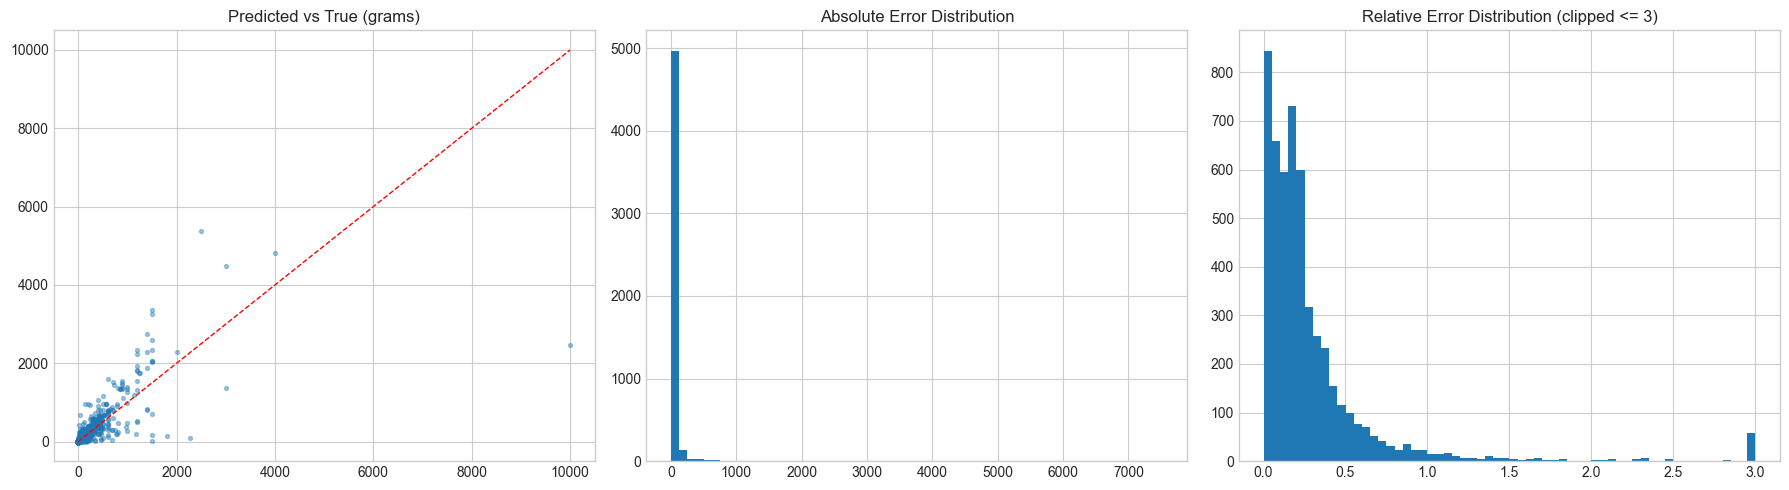

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/artifacts/deberta_v3_base_grams_text_input_final


In [33]:
# One-cell DeBERTa-v3 regression pipeline (same flow as the last T5 cell)
# text_input rule:
# - if unit exists: "{size} {unit} of {name}" (size empty -> "1 {unit} of {name}")
# - if unit is empty: "{size} {name}" (size empty -> "1 {name}")

import json
import os
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

plt.style.use('seaborn-v0_8-whitegrid')

# -----------------------------
# 1) Load cleaned dataset
# -----------------------------
DATA_PATH = Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/final_unit_removed.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Not found: {DATA_PATH.resolve()}')

with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

# Keep full-precision path to avoid Float/Half backward mismatch on some setups.
os.environ['ACCELERATE_MIXED_PRECISION'] = 'no'


def norm(x):
    return str(x or '').strip().lower()

def get_a_or_an(word):
    if not word: return "a"
    return "an" if word[0].lower() in 'aeiou' else "a"

def build_text_input(r):
    size = norm(r.get('size', ''))
    unit = norm(r.get('unit', ''))
    name = norm(r.get('name', ''))
    qty = r.get('quantity', 1)

    try:
        qty = float(qty) if qty else 1.0
    except Exception:
        qty = 1.0

    if unit:
        if qty == 1.0:
            article = get_a_or_an(unit)
            prefix = f"{article} {size}".strip()
        else:
            qty_str = int(qty) if qty == int(qty) else qty
            prefix = f"{qty_str} {size}".strip()
        return f"{prefix} {unit} of {name}".strip().replace("  ", " ")
    else:
        if qty == 1.0:
            article = get_a_or_an(size if size else name)
            prefix = f"{article} {size}".strip()
        else:
            qty_str = int(qty) if qty == int(qty) else qty
            prefix = f"{qty_str} {size}".strip()
        return f"{prefix} {name}".strip().replace("  ", " ")


records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue

    records.append({
        'text_input': build_text_input(r),
        'label': gram,
    })

df = pd.DataFrame(records, columns=['text_input', 'label'])
if df.empty:
    raise ValueError('No usable rows after filtering (gram>0). Check DATA_PATH and input JSON schema.')

df['label'] = np.log1p(df['label']).astype(np.float32)
print(f'Loaded rows: {len(rows)}')
print(f'Usable rows (gram>0): {len(df)}')
print('\nExamples:')
display(df.head(20))

# Optional downsample for quicker test
MAX_ROWS = None  # quick smoke run; set None for full
if MAX_ROWS and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print(f'Downsampled rows: {len(df)}')

# -----------------------------
# 2) Split + tokenize
# -----------------------------
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_ds = Dataset.from_pandas(train_df[['text_input', 'label']])
val_ds = Dataset.from_pandas(val_df[['text_input', 'label']])

MODEL_NAME =  'microsoft/deberta-v3-base' #'MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33'
MAX_INPUT_LEN = 96

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type='regression',
    ignore_mismatched_sizes=True,
)
model = model.float()


def preprocess(examples):
    return tokenizer(
        examples['text_input'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )


train_tok = train_ds.map(preprocess, batched=True, remove_columns=['text_input'])
val_tok = val_ds.map(preprocess, batched=True, remove_columns=['text_input'])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------------
# 3) Train
# -----------------------------
MAX_EPOCHS = 50  # train long, stop early when val loss stops improving
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_THRESHOLD = 0.0
IS_WINDOWS = platform.system().lower() == 'windows'
DATALOADER_NUM_WORKERS = 0  # keep 0 on macOS notebooks to avoid worker crashes
FORCE_CPU = False
print('MPS available:', torch.backends.mps.is_available())

args = TrainingArguments(
    output_dir='artifacts/deberta_v3_base_grams_text_input',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=1e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=MAX_EPOCHS,
    weight_decay=0.01,
    logging_steps=20,
    fp16=False,
    bf16=False,
    use_cpu=FORCE_CPU,
    dataloader_pin_memory=False,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
        )
    ],
)

train_output = trainer.train()
print(train_output)
print(f"best checkpoint: {trainer.state.best_model_checkpoint}")
print(f"best eval_loss: {trainer.state.best_metric}")

# make sure evaluation/saving uses the best model loaded at end
model = trainer.model

# -----------------------------
# 4) Evaluate (same style)
# -----------------------------
pred_output = trainer.predict(val_tok)
pred_vals = np.asarray(pred_output.predictions).squeeze(-1).astype(np.float64)
true_vals = val_df['label'].values.astype(np.float64)

pred_ok = np.expm1(np.maximum(pred_vals, 0))
true_ok = np.expm1(true_vals)

mae = mean_absolute_error(true_ok, pred_ok)
mape = np.mean(np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) * 100
within20 = np.mean((np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) <= 0.2)
parse_rate = 1.0

metrics_df = pd.DataFrame([
    {'metric': 'parse_success_rate', 'value': parse_rate},
    {'metric': 'MAE_g', 'value': mae},
    {'metric': 'MAPE_pct', 'value': mape},
    {'metric': 'within_20pct', 'value': within20},
])

print('Evaluation metrics:')
display(metrics_df)

res = pd.DataFrame({'y_true': true_ok, 'y_pred': pred_ok})
res['abs_err'] = (res['y_true'] - res['y_pred']).abs()
res['rel_err'] = res['abs_err'] / np.maximum(res['y_true'].abs(), 1e-8)

# range table
bins = [0, 50, 200, np.inf]
labels = ['0-50g', '50-200g', '200g+']
res['range_bin'] = pd.cut(res['y_true'], bins=bins, labels=labels, include_lowest=True)
range_metrics = res.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'mae_g': g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()

print('Range metrics:')
display(range_metrics)

# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(res['y_true'], res['y_pred'], s=8, alpha=0.4)
mn = min(res['y_true'].min(), res['y_pred'].min())
mx = max(res['y_true'].max(), res['y_pred'].max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_title('Predicted vs True (grams)')

axes[1].hist(res['abs_err'], bins=60)
axes[1].set_title('Absolute Error Distribution')

axes[2].hist(np.clip(res['rel_err'], 0, 3), bins=60)
axes[2].set_title('Relative Error Distribution (clipped <= 3)')

plt.tight_layout()
plt.show()

# save model
save_dir = Path('artifacts/deberta_v3_base_grams_text_input_final')
save_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'Saved model to: {save_dir.resolve()}')


### New Chart and Evaluation with model

Validation samples: 5197


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Map:   0%|          | 0/5197 [00:00<?, ? examples/s]


────────────────────────────────────────
  MAE (g)       : 38.87
  MAPE (%)      : 40.46
  Within ±20%   : 54.4%
────────────────────────────────────────

range_bin  count      mae_g  mape_pct  within20
   0–50 g 2320.0   4.972020 55.252387  0.628879
 50–200 g 1762.0  37.010749 30.352781  0.484109
   200 g+ 1115.0 112.362853 25.650032  0.462780


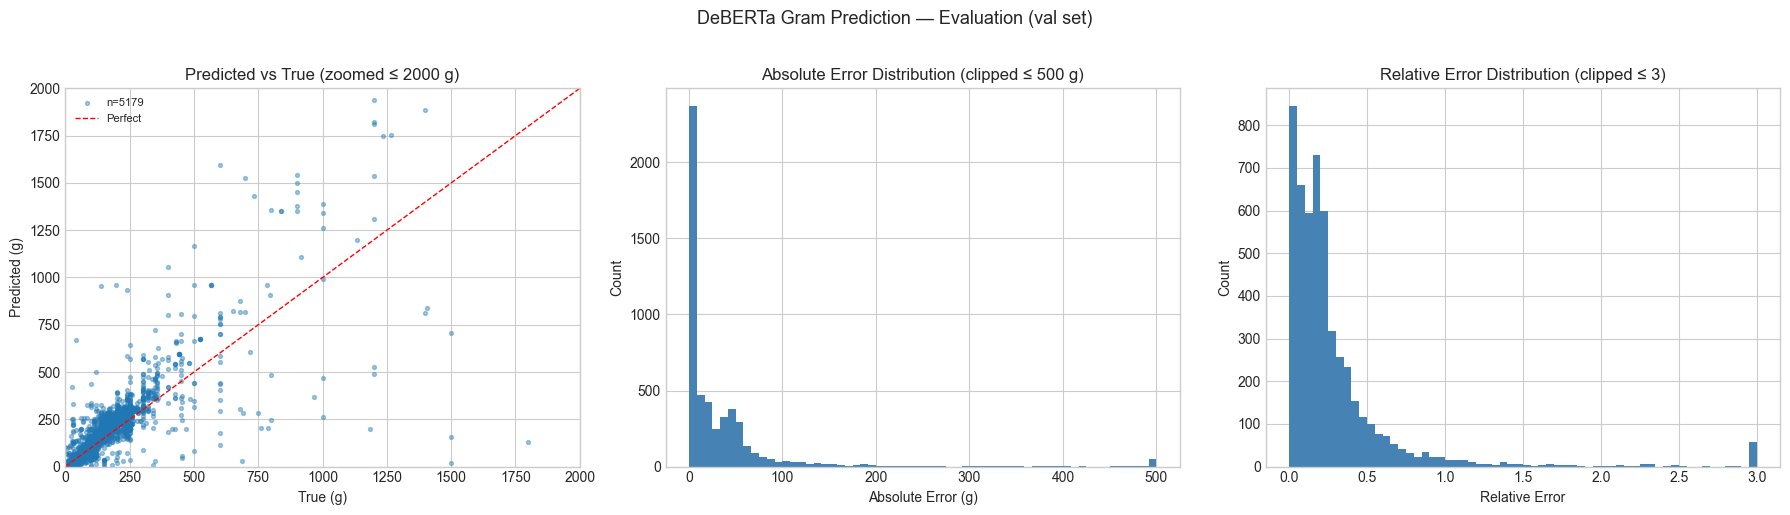

Saved → deberta_eval_improved.png


In [1]:
import json
import os
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

plt.style.use('seaborn-v0_8-whitegrid')

# ----------------------------------------
# 0) Config — 경로만 여기서 바꾸면 됨
# ----------------------------------------
DATA_PATH  = Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/final_unit_removed.json')
MODEL_PATH = Path('artifacts/deberta_v3_base_grams_text_input_final')  # save_pretrained 했던 경로
MAX_INPUT_LEN = 96

# ----------------------------------------
# 1) 데이터 로드 & 전처리 (학습 때와 동일)
# ----------------------------------------
with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

def norm(x):
    return str(x or '').strip().lower()

def get_a_or_an(word):
    if not word: return "a"
    return "an" if word[0].lower() in 'aeiou' else "a"

def build_text_input(r):
    size = norm(r.get('size', ''))
    unit = norm(r.get('unit', ''))
    name = norm(r.get('name', ''))
    qty  = r.get('quantity', 1)
    try:
        qty = float(qty) if qty else 1.0
    except Exception:
        qty = 1.0

    if unit:
        if qty == 1.0:
            article = get_a_or_an(unit)
            prefix  = f"{article} {size}".strip()
        else:
            qty_str = int(qty) if qty == int(qty) else qty
            prefix  = f"{qty_str} {size}".strip()
        return f"{prefix} {unit} of {name}".strip().replace("  ", " ")
    else:
        if qty == 1.0:
            article = get_a_or_an(size if size else name)
            prefix  = f"{article} {size}".strip()
        else:
            qty_str = int(qty) if qty == int(qty) else qty
            prefix  = f"{qty_str} {size}".strip()
        return f"{prefix} {name}".strip().replace("  ", " ")

records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue
    records.append({'text_input': build_text_input(r), 'label': gram})

df = pd.DataFrame(records, columns=['text_input', 'label'])
df['label_log'] = np.log1p(df['label']).astype(np.float32)

# 학습 때와 동일한 split → val set만 사용
_, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Validation samples: {len(val_df)}")

# ----------------------------------------
# 2) 모델 & 토크나이저 로드
# ----------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=1,
    problem_type='regression',
    ignore_mismatched_sizes=True,
).float()

# ----------------------------------------
# 3) Tokenize val set
# ----------------------------------------
val_ds = Dataset.from_pandas(val_df[['text_input', 'label_log']].rename(columns={'label_log': 'label'}))

def preprocess(examples):
    return tokenizer(examples['text_input'], max_length=MAX_INPUT_LEN, truncation=True)

val_tok  = val_ds.map(preprocess, batched=True, remove_columns=['text_input'])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ----------------------------------------
# 4) Predict
# ----------------------------------------
args = TrainingArguments(
    output_dir='_tmp_eval',
    per_device_eval_batch_size=32,
    fp16=False, bf16=False,
    dataloader_pin_memory=False,
    report_to='none',
)
trainer = Trainer(model=model, args=args, processing_class=tokenizer, data_collator=collator)

pred_output = trainer.predict(val_tok)
pred_log    = np.asarray(pred_output.predictions).squeeze(-1).astype(np.float64)
true_log    = val_df['label_log'].values.astype(np.float64)

pred_g = np.expm1(np.maximum(pred_log, 0))
true_g = np.expm1(true_log)

# ----------------------------------------
# 5) Metrics
# ----------------------------------------
abs_err = np.abs(true_g - pred_g)
rel_err = abs_err / np.maximum(true_g, 1e-8)

mae       = abs_err.mean()
mape      = rel_err.mean() * 100
within20  = (rel_err <= 0.2).mean()

print(f"\n{'─'*40}")
print(f"  MAE (g)       : {mae:.2f}")
print(f"  MAPE (%)      : {mape:.2f}")
print(f"  Within ±20%   : {within20*100:.1f}%")
print(f"{'─'*40}\n")

res = pd.DataFrame({'y_true': true_g, 'y_pred': pred_g, 'abs_err': abs_err, 'rel_err': rel_err})

bins   = [0, 50, 200, np.inf]
labels = ['0–50 g', '50–200 g', '200 g+']
res['range_bin'] = pd.cut(res['y_true'], bins=bins, labels=labels, include_lowest=True)

range_tbl = res.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count':    len(g),
        'mae_g':    g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()
print(range_tbl.to_string(index=False))

# ----------------------------------------
# 6) 개선된 시각화
# ----------------------------------------
ZOOM_MAX_G = 2000   # ← Predicted vs True 줌 범위
ABS_CLIP   = 500    # ← Absolute Error x축 상한

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DeBERTa Gram Prediction — Evaluation (val set)', fontsize=13, y=1.02)

# --- (A) Predicted vs True, zoomed ---
ax = axes[0]
mask = (res['y_true'] <= ZOOM_MAX_G) & (res['y_pred'] <= ZOOM_MAX_G)
ax.scatter(res.loc[mask, 'y_true'], res.loc[mask, 'y_pred'],
           s=8, alpha=0.4, label=f'n={mask.sum()}')
ax.plot([0, ZOOM_MAX_G], [0, ZOOM_MAX_G], 'r--', linewidth=1, label='Perfect')
ax.set_xlim(0, ZOOM_MAX_G)
ax.set_ylim(0, ZOOM_MAX_G)
ax.set_title(f'Predicted vs True (zoomed ≤ {ZOOM_MAX_G} g)')
ax.set_xlabel('True (g)')
ax.set_ylabel('Predicted (g)')
ax.legend(fontsize=8)

# --- (B) Absolute Error, x축 클리핑 ---
ax = axes[1]
clipped_abs = np.clip(res['abs_err'], 0, ABS_CLIP)
ax.hist(clipped_abs, bins=60, color='steelblue', edgecolor='none')
ax.set_title(f'Absolute Error Distribution (clipped ≤ {ABS_CLIP} g)')
ax.set_xlabel('Absolute Error (g)')
ax.set_ylabel('Count')

# --- (C) Relative Error, 그대로 유지 ---
ax = axes[2]
ax.hist(np.clip(res['rel_err'], 0, 3), bins=60, color='steelblue', edgecolor='none')
ax.set_title('Relative Error Distribution (clipped ≤ 3)')
ax.set_xlabel('Relative Error')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('deberta_eval_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → deberta_eval_improved.png")

### Why result appeared like that

Total usable rows: 25983
Val rows: 5197


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Map:   0%|          | 0/5197 [00:00<?, ? examples/s]

true_ok sample: [240.00001624 199.9999526    3.50000017  29.99999802 250.00003804]
pred_ok sample: [284.4437837  238.28844711   3.61981976  31.33631187 289.72660051]

Overall MAE:  38.87 g
Overall MAPE: 40.46 %
Within ±20%:  54.4 %


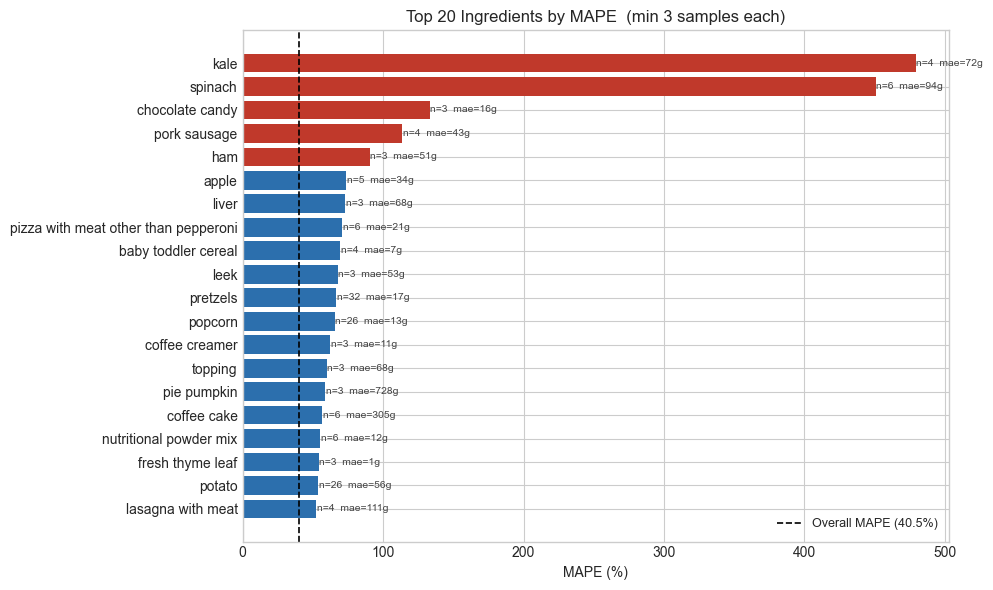

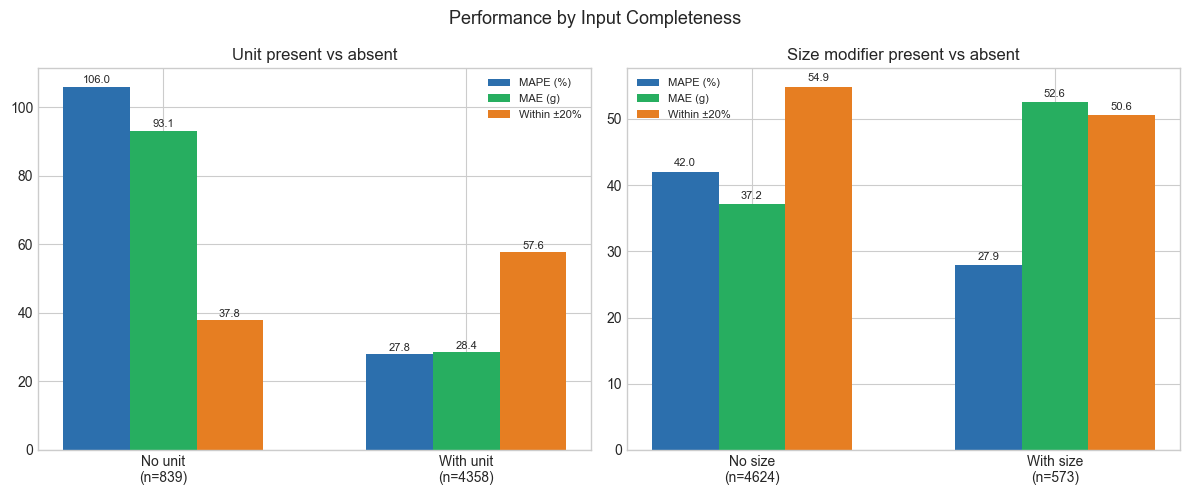

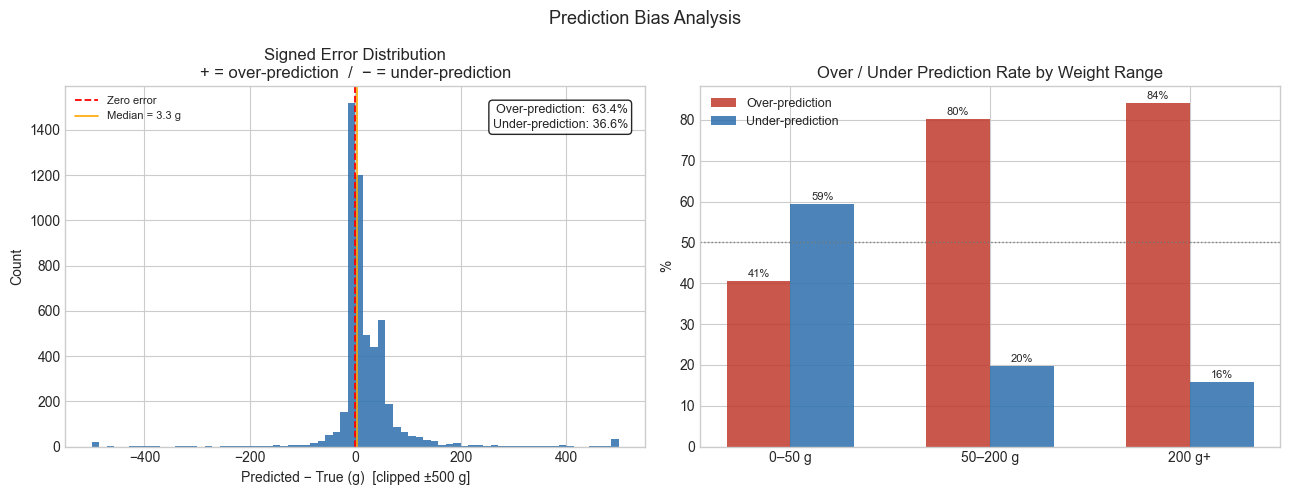

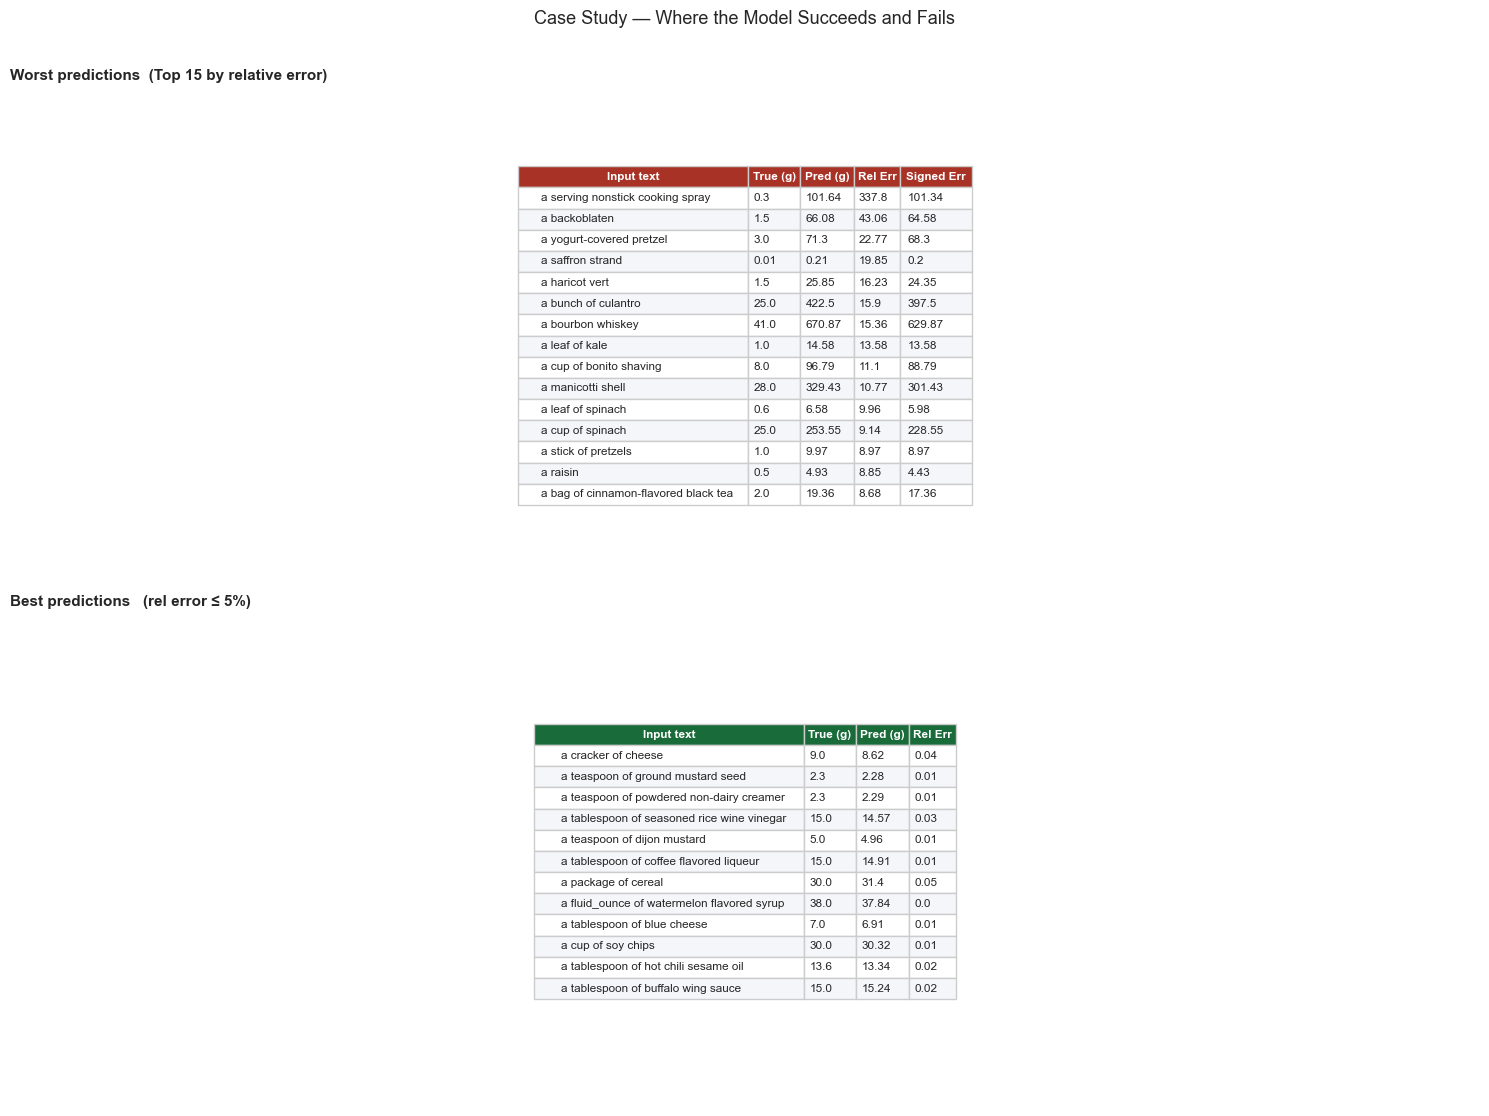


Saved:
  fig1_worst_ingredients.png
  fig2_input_completeness.png
  fig3_bias_analysis.png
  fig4_case_study.png


In [10]:
# ================================================
# Fully self-contained Error Analysis Cell
# — only needs DATA_PATH and MODEL_PATH
# — does NOT depend on val_df / true_ok / pred_ok
# ================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH  = Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/final_unit_removed.json')
MODEL_PATH = Path('artifacts/deberta_v3_base_grams_text_input_final')
MAX_INPUT_LEN = 96

# ----------------------------------------
# Step 1. Load & build records
# ----------------------------------------
with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

def norm(x):
    return str(x or '').strip().lower()

def get_a_or_an(w):
    return 'an' if w and w[0].lower() in 'aeiou' else 'a'

def build_text_input(r):
    size = norm(r.get('size', ''))
    unit = norm(r.get('unit', ''))
    name = norm(r.get('name', ''))
    qty  = r.get('quantity', 1)
    try:
        qty = float(qty) if qty else 1.0
    except Exception:
        qty = 1.0
    if unit:
        prefix = f"{get_a_or_an(unit)} {size}".strip() if qty == 1.0 \
                 else f"{int(qty) if qty == int(qty) else qty} {size}".strip()
        return f"{prefix} {unit} of {name}".strip().replace('  ', ' ')
    else:
        prefix = f"{get_a_or_an(size or name)} {size}".strip() if qty == 1.0 \
                 else f"{int(qty) if qty == int(qty) else qty} {size}".strip()
        return f"{prefix} {name}".strip().replace('  ', ' ')

records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue
    records.append({
        'text_input': build_text_input(r),
        'label':      np.float32(np.log1p(gram)),
        'gram':       gram,
        'name':       norm(r.get('name', '')),
        'unit':       norm(r.get('unit', '')),
        'size':       norm(r.get('size', '')),
    })

full_df = pd.DataFrame(records)
print(f"Total usable rows: {len(full_df)}")

# ----------------------------------------
# Step 2. Reproduce val split
#         split on text_input+label only → same as training cell
# ----------------------------------------
_, val_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=42
)
val_df = val_df.reset_index(drop=True)
print(f"Val rows: {len(val_df)}")

# ----------------------------------------
# Step 3. Load model & predict
# ----------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=1,
    problem_type='regression',
    ignore_mismatched_sizes=True,
).float()

val_ds = Dataset.from_pandas(val_df[['text_input', 'label']])

def preprocess(examples):
    return tokenizer(examples['text_input'], max_length=MAX_INPUT_LEN, truncation=True)

val_tok  = val_ds.map(preprocess, batched=True, remove_columns=['text_input'])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir='_tmp_analysis',
        per_device_eval_batch_size=32,
        fp16=False, bf16=False,
        dataloader_pin_memory=False,
        report_to='none',
    ),
    processing_class=tokenizer,
    data_collator=collator,
)

pred_out = trainer.predict(val_tok)
pred_log = np.asarray(pred_out.predictions).squeeze(-1).astype(np.float64)
true_log = val_df['label'].values.astype(np.float64)

true_ok = np.expm1(true_log)
pred_ok = np.expm1(np.maximum(pred_log, 0))

print(f"true_ok sample: {true_ok[:5]}")
print(f"pred_ok sample: {pred_ok[:5]}")

# ----------------------------------------
# Step 4. Build res
# ----------------------------------------
res = val_df[['text_input', 'name', 'unit', 'size', 'gram']].copy()
res['y_true']     = true_ok
res['y_pred']     = pred_ok
res['abs_err']    = np.abs(res['y_true'] - res['y_pred'])
res['rel_err']    = res['abs_err'] / np.maximum(res['y_true'], 1e-8)
res['signed_err'] = res['y_pred'] - res['y_true']
res['has_unit']   = res['unit'].apply(lambda x: 'With unit' if x else 'No unit')
res['has_size']   = res['size'].apply(lambda x: 'With size' if x else 'No size')

bins  = [0, 50, 200, np.inf]
blbls = ['0–50 g', '50–200 g', '200 g+']
res['range_bin'] = pd.cut(res['y_true'], bins=bins, labels=blbls, include_lowest=True)

print(f"\nOverall MAE:  {res['abs_err'].mean():.2f} g")
print(f"Overall MAPE: {res['rel_err'].mean()*100:.2f} %")
print(f"Within ±20%:  {(res['rel_err']<=0.2).mean()*100:.1f} %")

# ================================================
# Figure 1 — Top 20 worst ingredients by MAPE
# ================================================
name_grp = (
    res.groupby('name')
       .agg(count=('abs_err','count'), mape=('rel_err','mean'), mae=('abs_err','mean'))
       .query('count >= 3')
       .nlargest(20, 'mape')
       .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c0392b' if m > 0.8 else '#2c6fad' for m in name_grp['mape'][::-1]]
bars = ax.barh(name_grp['name'][::-1], name_grp['mape'][::-1] * 100, color=colors)
overall_mape = res['rel_err'].mean() * 100
ax.axvline(overall_mape, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall MAPE ({overall_mape:.1f}%)')
ax.set_xlabel('MAPE (%)')
ax.set_title('Top 20 Ingredients by MAPE  (min 3 samples each)', fontsize=12)
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars[::-1], name_grp.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['count'])}  mae={row['mae']:.0f}g",
            va='center', fontsize=7.5, color='#444')
plt.tight_layout()
plt.savefig('fig1_worst_ingredients.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================
# Figure 2 — Performance by input completeness
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Performance by Input Completeness', fontsize=13)

for ax, col, title in zip(
    axes,
    ['has_unit', 'has_size'],
    ['Unit present vs absent', 'Size modifier present vs absent']
):
    grp = res.groupby(col).agg(
        mape    =('rel_err', 'mean'),
        mae     =('abs_err', 'mean'),
        within20=('rel_err', lambda x: (x <= 0.2).mean()),
        count   =('rel_err', 'count'),
    ).reset_index()

    x = np.arange(len(grp))
    w = 0.22
    b1 = ax.bar(x - w, grp['mape']     * 100, width=w, label='MAPE (%)',    color='#2c6fad')
    b2 = ax.bar(x,     grp['mae'],             width=w, label='MAE (g)',     color='#27ae60')
    b3 = ax.bar(x + w, grp['within20'] * 100,  width=w, label='Within ±20%',color='#e67e22')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r[col]}\n(n={int(r['count'])})" for _, r in grp.iterrows()])
    ax.set_title(title)
    ax.legend(fontsize=8)
    for bars_grp, vals in [(b1, grp['mape']*100), (b2, grp['mae']), (b3, grp['within20']*100)]:
        for bar, v in zip(bars_grp, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig2_input_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================
# Figure 3 — Bias analysis
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Prediction Bias Analysis', fontsize=13)

ax = axes[0]
clipped = np.clip(res['signed_err'], -500, 500)
ax.hist(clipped, bins=70, color='#2c6fad', edgecolor='none', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.3, label='Zero error')
ax.axvline(res['signed_err'].median(), color='orange', linestyle='-', linewidth=1.2,
           label=f"Median = {res['signed_err'].median():.1f} g")
ax.set_xlabel('Predicted − True (g)  [clipped ±500 g]')
ax.set_ylabel('Count')
ax.set_title('Signed Error Distribution\n+ = over-prediction  /  − = under-prediction')
over  = (res['signed_err'] > 0).mean() * 100
under = (res['signed_err'] < 0).mean() * 100
ax.text(0.97, 0.95,
        f'Over-prediction:  {over:.1f}%\nUnder-prediction: {under:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85))
ax.legend(fontsize=8)

ax = axes[1]
dir_grp = (
    res.groupby('range_bin', observed=False)['signed_err']
       .apply(lambda x: pd.Series({
           'Over-pred':  (x > 0).mean() * 100,
           'Under-pred': (x < 0).mean() * 100,
       }))
       .unstack()
)
xp = np.arange(len(dir_grp))
w  = 0.32
ax.bar(xp - w/2, dir_grp['Over-pred'],  width=w, label='Over-prediction',  color='#c0392b', alpha=0.85)
ax.bar(xp + w/2, dir_grp['Under-pred'], width=w, label='Under-prediction', color='#2c6fad', alpha=0.85)
ax.axhline(50, color='gray', linestyle=':', linewidth=1)
ax.set_xticks(xp)
ax.set_xticklabels(dir_grp.index)
ax.set_ylabel('%')
ax.set_title('Over / Under Prediction Rate by Weight Range')
ax.legend(fontsize=9)
for container in [ax.containers[0], ax.containers[1]]:
    for bar in container:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig3_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================
# Figure 4 — Case study table
# ================================================
worst = (
    res.nlargest(15, 'rel_err')
       [['text_input', 'y_true', 'y_pred', 'rel_err', 'signed_err']]
       .copy()
)
worst.columns = ['Input text', 'True (g)', 'Pred (g)', 'Rel Err', 'Signed Err']
worst = worst.round(2)

best_pool = res[res['rel_err'] <= 0.05]
best = (
    best_pool.sample(min(12, len(best_pool)), random_state=42)
             [['text_input', 'y_true', 'y_pred', 'rel_err']]
             .copy()
)
best.columns = ['Input text', 'True (g)', 'Pred (g)', 'Rel Err']
best = best.round(2)

def draw_table(ax, df, title, header_color):
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left', pad=8)
    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='left',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.auto_set_column_width(col=list(range(len(df.columns))))
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#f4f6f9')
        else:
            cell.set_facecolor('white')

fig, axes = plt.subplots(2, 1, figsize=(15, 11))
fig.suptitle('Case Study — Where the Model Succeeds and Fails', fontsize=13, y=1.01)
draw_table(axes[0], worst, 'Worst predictions  (Top 15 by relative error)', '#a93226')
draw_table(axes[1], best,  'Best predictions   (rel error ≤ 5%)',           '#1a6b3a')
plt.tight_layout()
plt.savefig('fig4_case_study.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSaved:')
print('  fig1_worst_ingredients.png')
print('  fig2_input_completeness.png')
print('  fig3_bias_analysis.png')
print('  fig4_case_study.png')

### Food.xlsx 필터링

In [ ]:
# Convert scrape/food.xlsx to JSON (records)
from pathlib import Path
import json
import pandas as pd

candidate_xlsx_paths = [
    Path('scrape/food.xlsx'),
    Path('food_model/gptgram_model/scrape/food.xlsx'),
]

xlsx_path = next((p for p in candidate_xlsx_paths if p.exists()), None)
if xlsx_path is None:
    raise FileNotFoundError(
        'food.xlsx not found. Checked: ' + ', '.join(str(p) for p in candidate_xlsx_paths)
    )

out_path = xlsx_path.with_suffix('.json')

# Row 0 is a title row; actual headers are on row 1.
df_food = pd.read_excel(xlsx_path, header=1)

# Clean column names and remove fully empty rows.
df_food.columns = [str(c).strip().replace('\n', ' ') for c in df_food.columns]
df_food = df_food.dropna(how='all').reset_index(drop=True)

# Convert NaN -> None for valid JSON.
records = (
    df_food
    .where(pd.notna(df_food), None)
    .to_dict(orient='records')
)

with out_path.open('w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print(f'Rows: {len(df_food):,}')
print(f'Columns: {len(df_food.columns)}')
print(f'Saved JSON: {out_path.resolve()}')
print('Sample record:')
print(records[0] if records else 'No records')

Rows: 22,046
Columns: 7
Saved JSON: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food.json
Sample record:
{'Food code': 11000000, 'Main food description': 'Milk, human', 'WWEIA Category number': 9602, 'WWEIA Category description': 'Human milk', 'Seq num': 1, 'Portion description': '1 cup', 'Portion weight (g)': 246.0}


In [32]:
# List unique values of "WWEIA Category description" from food.json
from pathlib import Path
import json
import pandas as pd

candidate_json_paths = [
    Path('scrape/food.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError(
        'food.json not found. Checked: ' + ', '.join(str(p) for p in candidate_json_paths)
    )

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df_food = pd.DataFrame(rows)
col = 'WWEIA Category description'
if col not in df_food.columns:
    raise KeyError(f'Column not found: {col}. Available: {list(df_food.columns)}')

cats = (
    df_food[col]
    .fillna('')
    .astype(str)
    .str.strip()
)

cats_nonempty = cats[cats != '']
unique_cats = sorted(cats_nonempty.unique().tolist())
counts = cats_nonempty.value_counts().rename_axis(col).reset_index(name='count')

print(f'JSON path: {json_path.resolve()}')
print(f'Total rows: {len(df_food):,}')
print(f'Non-empty "{col}": {len(cats_nonempty):,}')
print(f'Unique categories: {len(unique_cats):,}')

print('\n[Unique category list]')
for c in unique_cats:
    print('-', c)

print('\n[Top counts]')
display(counts.head(50))

# Save full counts to file
out_csv = json_path.with_name('wweia_category_counts.csv')
counts.to_csv(out_csv, index=False, encoding='utf-8')
print(f'\nSaved: {out_csv.resolve()}')

JSON path: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food.json
Total rows: 22,046
Non-empty "WWEIA Category description": 22,046
Unique categories: 172

[Unique category list]
- Apple juice
- Apples
- Baby food: cereals
- Baby food: fruit
- Baby food: meat and dinners
- Baby food: mixtures
- Baby food: snacks and sweets
- Baby food: vegetables
- Baby food: yogurt
- Baby juice
- Baby water
- Bacon
- Bagels and English muffins
- Bananas
- Bean, pea, legume dishes
- Beans, peas, legumes
- Beef, excludes ground
- Beer
- Biscuits, muffins, quick breads
- Blueberries and other berries
- Bottled water
- Broccoli
- Burgers
- Burritos and tacos
- Butter and animal fats
- Cabbage
- Cakes and pies
- Candy containing chocolate
- Candy not containing chocolate
- Carrots
- Cereal bars
- Cheese
- Cheese sandwiches
- Chicken fillet sandwiches
- Chicken patties, nuggets and tenders
- Chicken, whole pieces
- Citrus fruits
- Citrus juice
- Coffee
- Cold cuts and c

,WWEIA Category description,count
0,Pizza,975
1,"Chicken, whole pieces",942
2,Fish,699
3,Yeast breads,687
4,Meat mixed dishes,651
5,Coffee,575
6,"Pasta mixed dishes, excludes macaroni and cheese",540
7,Cookies and brownies,481
8,Eggs and omelets,463
9,Other vegetables and combinations,460



Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/wweia_category_counts.csv


In [ ]:
# Sample 10 random rows per WWEIA category and save as JSON
from pathlib import Path
import json
import pandas as pd

candidate_json_paths = [
    Path('scrape/food.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError(
        'food.json not found. Checked: ' + ', '.join(str(p) for p in candidate_json_paths)
    )

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df = pd.DataFrame(rows)
col = 'WWEIA Category description'
if col not in df.columns:
    raise KeyError(f'Column not found: {col}. Available: {list(df.columns)}')

# Clean category text and drop empty categories
df[col] = df[col].fillna('').astype(str).str.strip()
df_nonempty = df[df[col] != ''].copy()

# Random 10 rows per category (or all rows if category has <10)
SAMPLES_PER_CATEGORY = 10
RANDOM_SEED = 42

# Use explicit concat to avoid pandas groupby-apply index quirks.
sampled_parts = []
for category_value, g in df_nonempty.groupby(col, sort=False):
    n = min(SAMPLES_PER_CATEGORY, len(g))
    sampled_parts.append(g.sample(n=n, random_state=RANDOM_SEED))

sampled = pd.concat(sampled_parts, ignore_index=True)

# Sort for readability (by category)
sampled = sampled.sort_values(by=col).reset_index(drop=True)

# Save JSON
out_json = json_path.with_name('wweia_category_random10.json')
out_records = sampled.where(pd.notna(sampled), None).to_dict(orient='records')
with out_json.open('w', encoding='utf-8') as f:
    json.dump(out_records, f, ensure_ascii=False, indent=2)

print(f'Total sampled rows: {len(sampled):,}')
print(f'Categories sampled: {sampled[col].nunique():,}')
print(f'Saved: {out_json.resolve()}')

# Additional output: save only Main food description, 5 random rows per category
main_col = 'Main food description'
if main_col not in df_nonempty.columns:
    raise KeyError(f'Column not found: {main_col}. Available: {list(df_nonempty.columns)}')

SAMPLES_PER_CATEGORY_MAIN = 5
main_parts = []
for category_value, g in df_nonempty.groupby(col, sort=False):
    n = min(SAMPLES_PER_CATEGORY_MAIN, len(g))
    sampled_g = g.sample(n=n, random_state=RANDOM_SEED)
    main_parts.append(sampled_g[[col, main_col]])

sampled_main = pd.concat(main_parts, ignore_index=True).sort_values(by=col).reset_index(drop=True)
out_json_main = json_path.with_name('wweia_category_main_food_random5.json')
out_records_main = sampled_main.where(pd.notna(sampled_main), None).to_dict(orient='records')
with out_json_main.open('w', encoding='utf-8') as f:
    json.dump(out_records_main, f, ensure_ascii=False, indent=2)

print(f'Saved (main food only, 5/category): {out_json_main.resolve()}')

# Show preview
display(sampled[[col]].value_counts().rename('count').reset_index())
display(sampled)
display(sampled_main)

Total sampled rows: 1,691
Categories sampled: 172
Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/wweia_category_random10.json
Saved (main food only, 5/category): /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/wweia_category_main_food_random5.json


,WWEIA Category description,count
0,Apple juice,10
1,Apples,10
2,Baby food: cereals,10
3,Baby food: fruit,10
4,Baby food: meat and dinners,10
...,...,...
167,Enhanced water,8
168,Strawberries,8
169,Baby water,3
170,Grapes,3


,Food code,Main food description,WWEIA Category number,WWEIA Category description,Seq num,Portion description,Portion weight (g)
0,64101010,Apple cider,7004,Apple juice,3,Quantity not specified,248.0
1,64101010,Apple cider,7004,Apple juice,4,1 fl oz (no ice),31.0
2,64104010,"Apple juice, 100%",7004,Apple juice,2,1 fl oz (with ice),23.0
3,64104030,"Apple juice, 100%, with calcium added",7004,Apple juice,3,1 fl oz (NFS),31.0
4,64104030,"Apple juice, 100%, with calcium added",7004,Apple juice,2,1 fl oz (with ice),23.0
...,...,...,...,...,...,...,...
1686,11433000,"Yogurt, nonfat milk, fruit",1820,"Yogurt, regular",3,"1 container, NFS",170.0
1687,11434300,"Yogurt, nonfat milk, flavors other than fruit",1820,"Yogurt, regular",2,1 6 oz container,170.0
1688,11434090,"Yogurt, NS as to type of milk, flavors other t...",1820,"Yogurt, regular",4,1 cup,245.0
1689,11434090,"Yogurt, NS as to type of milk, flavors other t...",1820,"Yogurt, regular",1,1 4 oz container,113.0


,WWEIA Category description,Main food description
0,Apple juice,Apple cider
1,Apple juice,Apple cider
2,Apple juice,"Apple juice, 100%"
3,Apple juice,"Apple juice, 100%, with calcium added"
4,Apple juice,"Apple juice, 100%, with calcium added"
...,...,...
849,"Yogurt, regular","Yogurt, NFS"
850,"Yogurt, regular","Yogurt, whole milk, fruit"
851,"Yogurt, regular","Yogurt, NS as to type of milk, plain"
852,"Yogurt, regular","Yogurt, NFS"


In [ ]:
# Count unique Portion description values and their frequencies
from pathlib import Path
import json
import pandas as pd

candidate_json_paths = [
    Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_dropped.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]
json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('food.json not found')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df_food = pd.DataFrame(rows)
portion_col = 'Portion description'
if portion_col not in df_food.columns:
    raise KeyError(f'Column not found: {portion_col}')

portion_counts = (
    df_food[portion_col]
    .fillna('')
    .astype(str)
    .str.strip()
    .value_counts()
    .rename_axis(portion_col)
    .reset_index(name='count')
)

# keep non-empty descriptions first
portion_counts_nonempty = portion_counts[portion_counts[portion_col] != ''].reset_index(drop=True)

print(f'food.json: {json_path.resolve()}')
print(f'total rows: {len(df_food):,}')
print(f'unique non-empty {portion_col}: {len(portion_counts_nonempty):,}')

display(portion_counts_nonempty.head(100))

# Optional save
out_csv = json_path.with_name('portion_description_counts.csv')
portion_counts_nonempty.to_csv(out_csv, index=False, encoding='utf-8')
print(f'Saved: {out_csv.resolve()}')

food.json: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_dropped.json
total rows: 1,301
unique non-empty Portion description: 135


,Portion description,count
0,1 cubic inch,374
1,1 surface inch,166
2,1 cup (8 fl oz),103
3,1 can (12 fl oz),38
4,1 bottle (16.9 fl oz or 500 ml),35
...,...,...
95,1 sandwich thin,1
96,1 cubic inch cornbread,1
97,1 Hostess package of 5 mini muffins (2 oz),1
98,1 Little Debbie package (twin wrapped),1


Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/portion_description_counts.csv


In [ ]:
# Count how many rows in food.json contain each unit keyword
# in "Portion description" (case-insensitive substring match),
# then save results to CSV.

from pathlib import Path
import json
import pandas as pd

# Paths
base = Path("food_model/gptgram_model/scrape")
json_path = base / "/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food.json"
unit_csv_path = base / "unit_counts_selected_input.csv"
out_csv_path = base / "unit_counts_in_food_portion_description.csv"

# Load data
with json_path.open("r", encoding="utf-8") as f:
    rows = json.load(f)

df = pd.DataFrame(rows)
if "Portion description" not in df.columns:
    raise KeyError(f"'Portion description' not found. Available columns: {list(df.columns)}")

units = (
    pd.read_csv(unit_csv_path)["unit"]
    .dropna()
    .astype(str)
    .str.strip()
    .tolist()
)

portion_text = df["Portion description"].fillna("").astype(str).str.lower()

# Count matches
result = []
for unit in units:
    key = unit.lower()
    cnt = int(portion_text.str.contains(key, regex=False).sum())
    result.append({
        "unit": unit,
        "match_count_in_portion_description": cnt
    })

result_df = pd.DataFrame(result).sort_values(
    "match_count_in_portion_description", ascending=False
).reset_index(drop=True)

# Save + preview
result_df.to_csv(out_csv_path, index=False, encoding="utf-8")
print(f"Saved: {out_csv_path.resolve()}")
display(result_df)

FileNotFoundError: [Errno 2] No such file or directory: 'food_model/gptgram_model/scrape/unit_counts_selected_input.csv'

In [ ]:
# Save only rows whose Portion description contains any selected unit
from pathlib import Path
import json
import re
import pandas as pd

candidate_json_paths = [
    Path('scrape/food.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]
candidate_unit_csv_paths = [
    Path('scrape/unit_counts_selected_input.csv'),
    Path('food_model/gptgram_model/scrape/unit_counts_selected_input.csv'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
unit_csv_path = next((p for p in candidate_unit_csv_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('food.json not found')
if unit_csv_path is None:
    raise FileNotFoundError('unit_counts_selected_input.csv not found')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df_food = pd.DataFrame(rows)
portion_col = 'Portion description'
if portion_col not in df_food.columns:
    raise KeyError(f'Column not found: {portion_col}')

unit_df = pd.read_csv(unit_csv_path)
if 'unit' not in unit_df.columns:
    raise KeyError("'unit' column not found in unit CSV")

units = (
    unit_df['unit']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)
units = sorted({u for u in units if u})
if not units:
    raise ValueError('No valid units found in unit CSV')

portion_text = df_food[portion_col].fillna('').astype(str).str.lower()

# substring match: include row if any unit appears in Portion description
pattern = '|'.join(re.escape(u) for u in units)
mask = portion_text.str.contains(pattern, regex=True)

matched = df_food[mask].copy().reset_index(drop=True)

# optional: keep which units matched per row
def extract_matched_units(text: str) -> list[str]:
    t = (text or '').lower()
    return [u for u in units if u in t]

matched['matched_units'] = matched[portion_col].fillna('').astype(str).apply(extract_matched_units)

out_json = json_path.with_name('food_portion_description_contains_selected_units.json')
out_records = matched.where(pd.notna(matched), None).to_dict(orient='records')
with out_json.open('w', encoding='utf-8') as f:
    json.dump(out_records, f, ensure_ascii=False, indent=2)

print(f'food.json rows: {len(df_food):,}')
print(f'matched rows : {len(matched):,}')
print(f'saved        : {out_json.resolve()}')

display(matched.head(20))

food.json rows: 22,046
matched rows : 9,220
saved        : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json


,Food code,Main food description,WWEIA Category number,WWEIA Category description,Seq num,Portion description,Portion weight (g),matched_units
0,11000000,"Milk, human",9602,Human milk,1,1 cup,246.0,[cup]
1,11100000,"Milk, NFS",1004,"Milk, reduced fat",1,1 cup,244.0,[cup]
2,11100000,"Milk, NFS",1004,"Milk, reduced fat",3,1 individual school container,244.0,[container]
3,11100000,"Milk, NFS",1004,"Milk, reduced fat",5,Guideline amount per cup of hot cereal,61.0,[cup]
4,11111000,"Milk, whole",1002,"Milk, whole",1,1 cup,244.0,[cup]
5,11111000,"Milk, whole",1002,"Milk, whole",3,1 individual school container,244.0,[container]
6,11111000,"Milk, whole",1002,"Milk, whole",5,Guideline amount per cup of hot cereal,61.0,[cup]
7,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",1,1 cup,244.0,[cup]
8,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",3,1 individual school container,244.0,[container]
9,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",5,Guideline amount per cup of hot cereal,61.0,[cup]


In [ ]:
# Move size words (large/medium/small) from `unit` into `size` key
from pathlib import Path
import json
import re

candidate_json_paths = [
    Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json'),
    Path('food_model/gptgram_model/scrape/output_filled_name_unit_removed.json'),
    Path('scrape/food_portion_description_contains_selected_units.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('No target json found in known paths')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected a JSON array of objects')

size_words = {'small', 'medium', 'large'}
word_pattern = re.compile(r'\b(small|medium|large)\b', re.IGNORECASE)

updated = []
moved_count = 0
for row in rows:
    if not isinstance(row, dict):
        updated.append(row)
        continue

    unit = str(row.get('Portion description', '') or '').strip()
    size = str(row.get('size', '') or '').strip()

    if not unit:
        updated.append(row)
        continue

    found_sizes = [m.group(1).lower() for m in word_pattern.finditer(unit)]
    found_sizes = [s for s in found_sizes if s in size_words]

    if not found_sizes:
        updated.append(row)
        continue

    # remove size words from unit text
    cleaned_unit = word_pattern.sub(' ', unit)
    cleaned_unit = re.sub(r'\s+', ' ', cleaned_unit).strip()

    # move to size key (preserve existing size if present)
    unique_found = []
    for s in found_sizes:
        if s not in unique_found:
            unique_found.append(s)
    moved_size_text = ' '.join(unique_found)

    if size:
        # append only if not already included
        size_tokens = size.lower().split()
        extra = [s for s in unique_found if s not in size_tokens]
        new_size = (size + ' ' + ' '.join(extra)).strip() if extra else size
    else:
        new_size = moved_size_text

    new_row = dict(row)
    new_row['unit'] = cleaned_unit
    new_row['size'] = new_size
    updated.append(new_row)
    moved_count += 1

out_json = json_path.with_name(json_path.stem + '_size_moved.json')
with out_json.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Input : {json_path.resolve()}')
print(f'Rows  : {len(rows):,}')
print(f'Moved : {moved_count:,}')
print(f'Saved : {out_json.resolve()}')

Input : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json
Rows  : 9,220
Moved : 0
Saved : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units_size_moved.json


In [ ]:
# (Updated) Add `size` and `unit` keys from Portion description
from pathlib import Path
import json
import re

candidate_json_paths = [
    Path('scrape/food_portion_description_contains_selected_units.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('Target json not found')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected a JSON array of objects')

size_pattern = re.compile(r'\b(small|medium|large)\b', re.IGNORECASE)
leading_num_pattern = re.compile(r'^\s*\d+(?:[./]\d+)?\s*')

updated = []
size_added_count = 0
unit_added_count = 0

for row in rows:
    if not isinstance(row, dict):
        updated.append(row)
        continue

    desc = str(row.get('Portion description', '') or '').strip().lower()
    new_row = dict(row)

    # size: extract from Portion description (always create key)
    size_match = size_pattern.search(desc)
    if size_match:
        new_row['size'] = size_match.group(1).lower()
        size_added_count += 1
    else:
        new_row['size'] = ''

    # unit: prefer matched_units, fallback to cleaned Portion description
    matched_units = new_row.get('matched_units', [])
    if isinstance(matched_units, list) and matched_units:
        new_row['unit'] = str(matched_units[0]).strip().lower()
        unit_added_count += 1
    else:
        cleaned = size_pattern.sub(' ', desc)
        cleaned = leading_num_pattern.sub('', cleaned)
        cleaned = re.sub(r'\s+', ' ', cleaned).strip()
        new_row['unit'] = cleaned
        if cleaned:
            unit_added_count += 1

    updated.append(new_row)

out_json = json_path.with_name(json_path.stem + '_with_size_unit.json')
with out_json.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Input      : {json_path.resolve()}')
print(f'Rows       : {len(rows):,}')
print(f'Size added : {size_added_count:,}')
print(f'Unit added : {unit_added_count:,}')
print(f'Saved      : {out_json.resolve()}')

Input      : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json
Rows       : 9,220
Size added : 1,310
Unit added : 9,220
Saved      : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units_with_size_unit.json


In [ ]:
# Apply KEEP / MERGE / DELETE rules to food_portion_description_contains_selected_units_with_size_unit.json
from pathlib import Path
import json
import re

src_path = Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units_with_size_unit.json')
if not src_path.exists():
    raise FileNotFoundError(f'Not found: {src_path}')

with src_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected JSON array')

# ---------- rule config ----------
SIZE_WORDS = ('small', 'medium', 'large', 'mini', 'thin', 'thick', 'regular', 'snack', 'extra large')

# canonical unit map by keyword priority
CANONICAL_UNIT_RULES = [
    (r'\btablespoon\b', 'tablespoon'),
    (r'\bteaspoon\b', 'teaspoon'),
    (r'\bcup\b', 'cup'),
    (r'\bscoop\b', 'scoop'),
    (r'\bstick\b|\bstring\b', 'stick'),
    (r'\bpacket\b|\benvelope\b', 'packet'),
    (r'\bpackage\b|\bprepackaged\b|\bmicrowavable package\b|\bbox \(3\.2 oz\)', 'package'),
    (r'\bjar\b', 'jar'),
    (r'\btub\b', 'tub'),
    (r'\bcan\b', 'can'),
    (r'\bcontainer\b', 'container'),
    (r'\bbox\b', 'box'),
    (r'\bbottle\b', 'bottle'),
    (r'\bcracker\b|\bcrispbread\b|\bpretzel chip\b|\bbagel chip\b', 'cracker'),
    (r'\bspear\b', 'spear'),
    (r'\bpod\b', 'pod'),
    (r'\bsprig\b', 'sprig'),
    (r'\bleaf\b|\bcabbage leaf\b', 'leaf'),
    (r'\bstalk\b', 'stalk'),
    (r'\bclove\b', 'clove'),
    (r'\bhead\b|\bfennel bulb\b', 'head'),
    (r'\bdrop\b', 'drop'),
    (r'\blink\b', 'link'),
    (r'\bloaf\b', 'loaf'),
    (r'\bstrip\b|\brib\b|\bfinger\b', 'strip'),
    (r'\bchunk\b', 'chunk'),
    (r'\bcube\b', 'cube'),
    (r'\bwedge\b', 'wedge'),
    (r'\bring\b', 'ring'),
    (r'\bball\b', 'ball'),
    (r'\bmeatball\b', 'meatball'),
    (r'\bdrumstick\b', 'drumstick'),
    (r'\bear\b', 'ear'),
    (r'\bslice\b', 'slice'),
    (r'\bpiece\b|\bsection\b', 'piece'),
    (r'\bbag\b', 'bag'),
    (r'\bbulb\b', 'bulb'),
]

# hard delete patterns from your policy (dimension/brand/guideline/ambiguous)
DELETE_PATTERNS = [
    r'guideline amount',
    r'topping from|topping per',
    r'juice of',
    r'\b\d+\s*(?:fl oz|oz|liter|l)\b',
    r'\b\d+\s*(?:inch|inches|foot|yard|dia|x)\b',
    r'\blinear inch\b|\bcubic inch\b|\bsurface inch\b',
    r'\bmovie theater size\b|\bsharing\b',
    r'\bkeurig cup\b|\bespresso cup\b|\bjuice box\b|\bpouch\b',
    r'\bmyoplex\b|\bmonster milk\b|\bsnapple\b|\boreo\b|\bkeebler\b|\bkashi\b|\bpizza hut\b|\bpapa john\b|\bhostess\b|\blittle debbie\b',
    r'\bjack-in-the-box\b|\bbanquet\b|\bjimmy dean\b|\bfamous brand\b',
    r'\bfootlong\b|\bshoestring\b|\bporcupine ball\b|\bcannelloni\b|\bmeringue\b',
    r'\bice cube\b|\bcup ice\b',
    r'\bthin\b$',
    r'\brecipe\b|\bbatch\b',
]
DELETE_RE = [re.compile(p, re.IGNORECASE) for p in DELETE_PATTERNS]

SIZE_RE = re.compile(r'\b(extra large|large|medium|small|mini|thin|thick|regular|snack)\b', re.IGNORECASE)


def normalize_space(s: str) -> str:
    return re.sub(r'\s+', ' ', s).strip()


def should_delete(desc: str) -> str:
    for rx in DELETE_RE:
        if rx.search(desc):
            return rx.pattern
    # explicit fractional delete rule from your note
    if desc.startswith('1/4 cup'):
        return 'fractional_1_4_cup_rule'
    return ''


def extract_size(desc: str, existing_size: str) -> str:
    found = [m.group(1).lower() for m in SIZE_RE.finditer(desc)]
    mapped = []
    for s in found:
        if s in ('mini', 'thin', 'snack'):
            mapped.append('small')
        elif s == 'thick' or s == 'extra large':
            mapped.append('large')
        elif s in ('small', 'medium', 'large'):
            mapped.append(s)
    mapped = list(dict.fromkeys(mapped))

    base = normalize_space((existing_size or '').lower())
    if not mapped:
        return base
    if base:
        base_tokens = base.split()
        extra = [s for s in mapped if s not in base_tokens]
        return normalize_space(base + ' ' + ' '.join(extra))
    return ' '.join(mapped)


def canonical_unit(desc: str, unit_hint: str) -> str:
    text = normalize_space(f"{unit_hint or ''} {desc or ''}").lower()
    for pat, canon in CANONICAL_UNIT_RULES:
        if re.search(pat, text, flags=re.IGNORECASE):
            return canon
    return normalize_space((unit_hint or '').lower())


kept_rows = []
deleted_rows = []

for row in rows:
    if not isinstance(row, dict):
        continue

    desc = normalize_space(str(row.get('Portion description', '') or '').lower())
    size_old = str(row.get('size', '') or '')
    unit_old = str(row.get('unit', '') or '')

    reason = should_delete(desc)
    if reason:
        r = dict(row)
        r['drop_reason'] = reason
        deleted_rows.append(r)
        continue

    unit_new = canonical_unit(desc, unit_old)
    size_new = extract_size(desc, size_old)

    r = dict(row)
    r['unit_normalized'] = unit_new
    r['size_normalized'] = size_new
    kept_rows.append(r)

out_keep = src_path.with_name('food_portion_description_unit_rules_applied.json')
out_drop = src_path.with_name('food_portion_description_unit_rules_dropped.json')

with out_keep.open('w', encoding='utf-8') as f:
    json.dump(kept_rows, f, ensure_ascii=False, indent=2)
with out_drop.open('w', encoding='utf-8') as f:
    json.dump(deleted_rows, f, ensure_ascii=False, indent=2)

print(f'Input rows   : {len(rows):,}')
print(f'Kept rows    : {len(kept_rows):,}')
print(f'Dropped rows : {len(deleted_rows):,}')
print(f'Kept file    : {out_keep.resolve()}')
print(f'Dropped file : {out_drop.resolve()}')

Input rows   : 9,220
Kept rows    : 7,919
Dropped rows : 1,301
Kept file    : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json
Dropped file : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_dropped.json


### 로컬 ai 써서 필터링

In [ ]:
# Extract `main_ingredient` from ingredient name using Qwen 3B
# Example: "all purpose flour" -> "flour"
from pathlib import Path
import json
import re
from typing import List

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# -----------------------------
# 1) Load source JSON
# -----------------------------
candidate_json_paths = [
    Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json'),
    Path('food_model/gptgram_model/scrape/output_filled_name_unit_removed.json'),
    Path('scrape/food_portion_description_unit_rules_applied.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json'),
]

src_path = next((p for p in candidate_json_paths if p.exists()), None)
if src_path is None:
    raise FileNotFoundError('No source JSON found in known paths')

with src_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected JSON array')

# Choose name field automatically
name_field_candidates = ['name', 'Main food description']
name_field = next((k for k in name_field_candidates if rows and isinstance(rows[0], dict) and k in rows[0]), None)
if name_field is None:
    raise KeyError(f'Could not find name field. Tried: {name_field_candidates}')

print(f'Source: {src_path.resolve()}')
print(f'Rows: {len(rows):,}')
print(f'Name field: {name_field}')

# -----------------------------
# 2) Load Qwen 3.5 (3B / 9B)
# -----------------------------
# Choose one: "3B" or "9B"
MODEL_SIZE = '9B'
MODEL_ID_MAP = {
    '9B': 'Qwen/Qwen2.5-3B-Instruct',
}
if MODEL_SIZE not in MODEL_ID_MAP:
    raise ValueError(f'Unsupported MODEL_SIZE: {MODEL_SIZE}. Use one of {list(MODEL_ID_MAP.keys())}')

MODEL_ID = MODEL_ID_MAP[MODEL_SIZE]

# Optional: if you downloaded manually, set local path here.
# Example: '/Users/kyungmin/models/Qwen3.5-9B-Instruct'
LOCAL_MODEL_PATH = None
MODEL_SOURCE = LOCAL_MODEL_PATH if LOCAL_MODEL_PATH else MODEL_ID

# Heavier models need smaller batches.
if MODEL_SIZE == '3B':
    BATCH_SIZE = 16
    MAX_ROWS = None
else:
    BATCH_SIZE = 4
    MAX_ROWS = 5

MAX_NEW_TOKENS = 6
# Set MAX_ROWS=None after smoke test if memory/time is stable.

if MAX_ROWS is not None:
    rows = rows[:MAX_ROWS]
    print(f'Using first {len(rows):,} rows (MAX_ROWS={MAX_ROWS})')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Model size: {MODEL_SIZE}')
print(f'Model source: {MODEL_SOURCE}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_SOURCE, padding_side='left')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_SOURCE,
    torch_dtype='auto',
    device_map='auto',
)

# -----------------------------
# 3) Prompt / generation helpers
# -----------------------------
SYSTEM_PROMPT = (
    'Extract only the core ingredient noun phrase in lowercase. '
    'Do not include thinking, explanation, punctuation, or extra text.'
)


def clean_output(text: str) -> str:
    t = (text or '').strip().lower()

    # Remove explicit thinking blocks if present.
    t = re.sub(r'<think>.*?</think>', '', t, flags=re.S)

    # Keep only first line to avoid multiline rambles.
    t = t.split('\n')[0].strip()

    # Trim surrounding symbols.
    t = re.sub(r'^[^a-zA-Z가-힣]+|[^a-zA-Z가-힣 ]+$', '', t)
    t = re.sub(r'\s+', ' ', t).strip()

    # Guardrails against malformed outputs.
    if not t:
        return ''
    if 'thinking' in t:
        return ''

    words = t.split()
    if len(words) > 4:
        t = ' '.join(words[:4])
    if len(t) > 30:
        return ''

    return t


def build_messages(name_text: str):
    return [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': f'ingredient: {name_text}\nReturn only core ingredient:'},
    ]


def infer_batch(names: List[str]) -> List[str]:
    prompts = []
    for n in names:
        msg = build_messages(n)
        prompt = tokenizer.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
        prompts.append(prompt)

    inputs = tokenizer(prompts, return_tensors='pt', padding=True, truncation=True).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=None,
            top_p=None,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_ids = out[:, inputs['input_ids'].shape[1]:]
    decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    return [clean_output(x) for x in decoded]

# -----------------------------
# 4) Run extraction and save
# -----------------------------
updated = []
for i in range(0, len(rows), BATCH_SIZE):
    batch_rows = rows[i:i + BATCH_SIZE]
    names = [str((r.get(name_field, '') if isinstance(r, dict) else '') or '') for r in batch_rows]
    preds = infer_batch(names)

    for r, pred in zip(batch_rows, preds):
        if isinstance(r, dict):
            new_r = dict(r)
            new_r['main_ingredient'] = pred
            updated.append(new_r)
        else:
            updated.append(r)

    if (i // BATCH_SIZE) % 20 == 0:
        print(f'Processed: {min(i + BATCH_SIZE, len(rows)):,}/{len(rows):,}')

out_path = src_path.with_name(src_path.stem + '_with_main_ingredient_qwen3b.json')
with out_path.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Saved: {out_path.resolve()}')
print('Sample:')
for s in updated[:10]:
    if isinstance(s, dict):
        print('-', s.get(name_field, ''), '=>', s.get('main_ingredient', ''))

Source: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json
Rows: 7,919
Name field: Main food description
Using first 5 rows (MAX_ROWS=5)
Device: cpu
Model size: 9B
Model source: Qwen/Qwen2.5-3B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


KeyboardInterrupt: 

In [ ]:
# Extract main_ingredient using ChatGPT API (OpenAI)
from pathlib import Path
import json
import re
import os

%pip install -U openai
from openai import OpenAI

# -----------------------------
# 1) API key / client
# -----------------------------
api_key = os.getenv('OPENAI_API_KEY')
if not api_key:
    raise ValueError('OPENAI_API_KEY is not set. Export it before running this cell.')

client = OpenAI(api_key=api_key)

# -----------------------------
# 2) Load source JSON
# -----------------------------
candidate_json_paths = [
    Path('scrape/food_portion_description_unit_rules_applied.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json'),
    Path('scrape/output_filled_name_unit_removed.json'),
    Path('food_model/gptgram_model/scrape/output_filled_name_unit_removed.json'),
]

src_path = next((p for p in candidate_json_paths if p.exists()), None)
if src_path is None:
    raise FileNotFoundError('No source JSON found in known paths')

with src_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected JSON array')

name_field_candidates = ['name', 'Main food description']
name_field = next((k for k in name_field_candidates if rows and isinstance(rows[0], dict) and k in rows[0]), None)
if name_field is None:
    raise KeyError(f'Could not find name field. Tried: {name_field_candidates}')

print(f'Source: {src_path.resolve()}')
print(f'Rows: {len(rows):,}')
print(f'Name field: {name_field}')

# -----------------------------
# 3) Settings
# -----------------------------
MODEL = 'gpt-4o-mini'
MAX_ROWS = 200  # set None for full run

if MAX_ROWS is not None:
    rows = rows[:MAX_ROWS]
    print(f'Using first {len(rows):,} rows (MAX_ROWS={MAX_ROWS})')


def clean_output(text: str) -> str:
    t = (text or '').strip().lower()
    t = t.split('\n')[0].strip()
    t = re.sub(r'\s+', ' ', t)
    t = re.sub(r'^[^a-zA-Z가-힣]+|[^a-zA-Z가-힣 ]+$', '', t)
    if len(t) > 40:
        t = t[:40].strip()
    return t


def extract_main_ingredient(name_text: str) -> str:
    response = client.chat.completions.create(
        model=MODEL,
        temperature=0,
        messages=[
            {
                'role': 'system',
                'content': (
                    'Extract only the core ingredient noun phrase from food text. '
                    'Return only final answer in lowercase. '
                    'No explanation, no punctuation.'
                ),
            },
            {'role': 'user', 'content': f'ingredient: "{name_text}"'},
        ],
    )
    return clean_output(response.choices[0].message.content)

# -----------------------------
# 4) Run and save
# -----------------------------
updated = []
for i, row in enumerate(rows, 1):
    if not isinstance(row, dict):
        updated.append(row)
        continue

    name_text = str(row.get(name_field, '') or '')
    main_ing = extract_main_ingredient(name_text)

    new_row = dict(row)
    new_row['main_ingredient'] = main_ing
    updated.append(new_row)

    if i % 20 == 0:
        print(f'Processed: {i:,}/{len(rows):,}')

out_path = src_path.with_name(src_path.stem + '_with_main_ingredient_chatgpt.json')
with out_path.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Saved: {out_path.resolve()}')
print('Sample:')
for s in updated[:10]:
    if isinstance(s, dict):
        print('-', s.get(name_field, ''), '=>', s.get('main_ingredient', ''))

In [ ]:
# Extract main_ingredient using Ollama (phi3 / llama3)
from pathlib import Path
import json
import re
import requests

# -----------------------------
# 0) Ollama settings
# -----------------------------
OLLAMA_URL = 'http://localhost:11434/api/chat'
OLLAMA_MODEL = 'qwen2.5:3b'  # examples: 'phi3', 'llama3', 'llama3:8b', 'llama3.2:3b'
REQUEST_TIMEOUT_SEC = 60

# -----------------------------
# 1) Load source JSON
# -----------------------------
candidate_json_paths = [
    Path('scrape/food_portion_description_unit_rules_applied.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json'),
    Path('scrape/output_filled_name_unit_removed.json'),
    Path('food_model/gptgram_model/scrape/output_filled_name_unit_removed.json'),
]

src_path = next((p for p in candidate_json_paths if p.exists()), None)
if src_path is None:
    raise FileNotFoundError('No source JSON found in known paths')

with src_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected JSON array')

name_field_candidates = ['name', 'Main food description']
name_field = next((k for k in name_field_candidates if rows and isinstance(rows[0], dict) and k in rows[0]), None)
if name_field is None:
    raise KeyError(f'Could not find name field. Tried: {name_field_candidates}')

print(f'Source: {src_path.resolve()}')
print(f'Rows: {len(rows):,}')
print(f'Name field: {name_field}')
print(f'Ollama model: {OLLAMA_MODEL}')

# Quick test before full run
MAX_ROWS = 30  # set None for full run
if MAX_ROWS is not None:
    rows = rows[:MAX_ROWS]
    print(f'Using first {len(rows):,} rows (MAX_ROWS={MAX_ROWS})')


def clean_output(text: str) -> str:
    t = (text or '').strip().lower()
    t = re.sub(r'<think>.*?</think>', '', t, flags=re.S)
    t = re.sub(r'^[^a-zA-Z]+', '', t)
    t = t.split('\n')[0].strip()
    t = re.sub(r'\s+', ' ', t)
    t = re.sub(r'[^a-zA-Z0-9 ]+$', '', t)
    if len(t) > 40:
        t = t[:40].strip()
    return t

def extract_main_ingredient_with_ollama(name_text: str, category_text: str = '') -> str:
    system_prompt = (
        'You are a food name parser. '
        'Extract the core food type from the food name.\n\n'
        'Rules:\n'
        '1. Take the noun phrase BEFORE the first comma in the food name.\n'
        '2. Remove fat content, sugar level, brand names, preparation method, serving descriptors.\n'
        '3. Keep modifier words only if they appear BEFORE the first comma AND change the food type '
        '(e.g. "frozen" in "Frozen yogurt", "greek" in "Yogurt, Greek").\n'
        '4. If the result is generic, use ONLY a word explicitly in the category. '
        'Never add words from your own knowledge.\n'
        '5. Output must be 1-4 words, lowercase, no punctuation.\n'
    )

    user_prompt = f'category: {category_text} | food: {name_text} ->'

    payload = {
        'model': OLLAMA_MODEL,
        'stream': False,
        'options': {'temperature': 0},
        'messages': [
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': user_prompt},
        ],
    }

    r = requests.post(OLLAMA_URL, json=payload, timeout=REQUEST_TIMEOUT_SEC)
    r.raise_for_status()
    data = r.json()
    content = data.get('message', {}).get('content', '')
    return clean_output(content)


# -----------------------------
# 2) Run and save
# -----------------------------
updated = []
for i, row in enumerate(rows, 1):
    if not isinstance(row, dict):
        updated.append(row)
        continue

    name_text = str(row.get(name_field, '') or '')
    category_text = str(row.get('WWEIA Category description', '') or '')
    try:
        main_ing = extract_main_ingredient_with_ollama(name_text, category_text)
    except Exception as e:
        main_ing = ''

    new_row = dict(row)
    new_row['main_ingredient'] = main_ing
    updated.append(new_row)

    if i % 20 == 0:
        print(f'Processed: {i:,}/{len(rows):,}')

out_path = src_path.with_name(src_path.stem + f'_with_main_ingredient_ollama_{OLLAMA_MODEL.replace(":", "_")}.json')
with out_path.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Saved: {out_path.resolve()}')
print('Sample:')
for s in updated[:10]:
    if isinstance(s, dict):
        print('-', s.get(name_field, ''), '=>', s.get('main_ingredient', ''))

Source: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json
Rows: 7,919
Name field: Main food description
Ollama model: qwen2.5:3b
Using first 30 rows (MAX_ROWS=30)
Processed: 20/30
Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied_with_main_ingredient_ollama_qwen2.5_3b.json
Sample:
- Milk, human => human-milk
- Milk, NFS => milk
- Milk, NFS => milk
- Milk, whole => whole milk
- Milk, whole => whole milk
- Milk, reduced fat (2%) => milk
- Milk, reduced fat (2%) => milk
- Milk, low fat (1%) => milk
- Milk, low fat (1%) => milk
- Milk, fat free (skim) => milk


### 더 간단하게 필터링, 첫번째 콤마전꺼 가져오기

In [ ]:
# Simple rule-based extraction: main_ingredient = text before first comma in food name
from pathlib import Path
import json
import re

candidate_json_paths = [
    Path('scrape/food_portion_description_unit_rules_applied.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json'),
]

src_path = next((p for p in candidate_json_paths if p.exists()), None)
if src_path is None:
    raise FileNotFoundError('Source JSON not found')

with src_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected JSON array')

name_field_candidates = ['Main food description', 'name']
name_field = next((k for k in name_field_candidates if rows and isinstance(rows[0], dict) and k in rows[0]), None)
if name_field is None:
    raise KeyError(f'Could not find food name field. Tried: {name_field_candidates}')


def extract_before_first_comma(text: str) -> str:
    t = str(text or '').strip().lower()
    t = t.split(',', 1)[0].strip()  # keep only before first comma
    t = t.replace('_', ' ').replace('-', ' ')
    t = re.sub(r'\s+', ' ', t)
    return t

updated = []
for row in rows:
    if not isinstance(row, dict):
        updated.append(row)
        continue

    name_text = row.get(name_field, '')
    main_ing = extract_before_first_comma(name_text)

    new_row = dict(row)
    new_row['main_ingredient'] = main_ing
    updated.append(new_row)

out_path = src_path.with_name(src_path.stem + '_with_main_ingredient_before_first_comma.json')
with out_path.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Source: {src_path.resolve()}')
print(f'Rows: {len(updated):,}')
print(f'Name field: {name_field}')
print(f'Saved: {out_path.resolve()}')
print('Sample:')
for s in updated[:10]:
    if isinstance(s, dict):
        print('-', s.get(name_field, ''), '=>', s.get('main_ingredient', ''))

Source: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json
Rows: 7,919
Name field: Main food description
Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied_with_main_ingredient_before_first_comma.json
Sample:
- Milk, human => milk
- Milk, NFS => milk
- Milk, NFS => milk
- Milk, whole => milk
- Milk, whole => milk
- Milk, reduced fat (2%) => milk
- Milk, reduced fat (2%) => milk
- Milk, low fat (1%) => milk
- Milk, low fat (1%) => milk
- Milk, fat free (skim) => milk


In [ ]:
from typing import Any
import pandas as pd

from pathlib import Path
import json
import re
from collections import Counter

base_dir = Path.cwd()
print(f'{base_dir}')

input_path =  base_dir / "scrape/food_portion_description_unit_rules_applied_with_main_ingredient_before_first_comma.json"
output_path = base_dir / "scrape/food_portion_description_converted.json"

with open(input_path, 'r', encoding= 'utf-8') as f:
    rows = json.load(f)

converted = []
for item in rows:
    new_item =  {
        "unit" : item.get("unit_normalized", ""),
        "size" : item.get("size_normalized", ""),
        "name" : item.get("main_ingredient", ""),
        "long_name" : item.get("Main food description", ""),
        "gram" : item.get("Portion weight (g)", ""),
    }

    converted.append(new_item)

unit_count = Counter(item["unit"] for item in converted)
sorted_count = unit_count.most_common()
df = pd.DataFrame(unit_count.most_common(), columns = ["unit", "count"])
df.to_csv("food_json_unit_count.csv", index = False, encoding="utf-8")
with open(output_path, 'w', encoding="utf-8") as f:
    json.dump(converted, f, ensure_ascii=False, indent=2)

# with open("food_json_unit_count.json", "w", encoding="utf-8") as f:
#     json.dump(sorted_count, f, ensure_ascii=False, indent=2)

print(f"Done {len(converted)} -> {output_path}")
display(df.head(15))
print(f'food_json_unit_count.json')

/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model
Done 7919 -> /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_converted.json


,unit,count
0,cup,3916
1,slice,1142
2,piece,599
3,bag,394
4,tablespoon,310
5,stick,249
6,container,239
7,package,232
8,can,109
9,packet,106


food_json_unit_count.json


In [29]:
%pwd

'/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model'

In [29]:
import json
from collections import Counter
import pandas as pd

input_path = ["/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/output_filled_name_unit_removed.json", 
"/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_converted.json"
]
output_path = "scrape/final.json"

merged_data =[]
for file in input_path:
    with open(file, "r", encoding = "utf-8") as f:
        data = json.load(f)
        for item in data:
            new_item = {
                "unit" : item.get("unit", ""),
                "size" : item.get("size", ""),
                "name" : item.get("name", ""),
                "gram" : item.get("gram", ""),
                "long_name" : item.get("long_name", "")
            }

            merged_data.append(new_item)

counted_unit = Counter(item["unit"] for item in merged_data).most_common()
df = pd.DataFrame(counted_unit, columns=["unit", "count"])
display(df.head(15))
df.to_csv("final_unit_counted.csv", index=False, encoding="utf-8")


with open(output_path, "w", encoding = "utf-8") as f:
    json.dump(merged_data, f, ensure_ascii=False, indent=2)
print(f'Total {len(merged_data)} rows -> {output_path}')


,unit,count
0,cup,10570
1,,4065
2,tablespoon,3445
3,teaspoon,1928
4,slice,1646
5,piece,668
6,fluid_ounce,427
7,bag,399
8,package,282
9,stick,271


Total 26140 rows -> scrape/final.json


In [1]:
import json
from collections import Counter
import pandas

input_path = '/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/output.json'

with open(input_path, "r", encoding="utf-8") as f:
    rows = json.load(f)
unit_count = Counter(item["unit"] for item in rows).most_common()
df = pandas.DataFrame(unit_count, columns = ["unit", "count"])
df.to_csv("unit_counter_for_check.csv", encoding="utf-8", index = False)

In [ ]:
from pathlib import Path
import pandas as pd
import json

# Load final.json and apply unit rules (DELETE list only; all others are kept)
CANDIDATE_PATHS = [
    Path('scrape/final.json'),
    Path('final.json'),
]
output_path = "final_unit_removed.json"

final_path = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if final_path is None:
    raise FileNotFoundError(
        "final.json not found. Place it at 'scrape/final.json' (or repo root 'final.json')."
    )

with final_path.open('r', encoding='utf-8') as f:
    raw_rows = json.load(f)

DELETE_UNITS = {
    'thin',
    'inch',
    'foot',
    'yard',
    'recipe',
    'batch',
    'grind',
    'metric_ton',
    'quarts_size',
    'part',
    'slab',
    'wheel',
    'canister',
    'block',
}

KEEP_UNITS = {
    'cup', 'tablespoon', 'teaspoon', 'slice', 'piece', 'bag', 'stick', 'container',
    'package', 'can', 'packet', 'fluid_ounce', 'pinch', 'bunch', 'dash', 'head',
    'drop', 'sprig', 'leaf', 'cracker', 'jar', 'ball', 'tub', 'link', 'sheet',
    'loaf', 'scoop', 'stalk', 'splash', 'cube', 'strip', 'ear', 'chunk', 'ring',
    'spear', 'wedge', 'square', 'pod', 'bottle', 'shot', 'box', 'rack', 'clove',
    'bulb', 'twist'
}

def normalize_unit(unit_value):
    u = str(unit_value or '').strip().lower()
    u = u.replace('-', '_').replace(' ', '_')
    while '__' in u:
        u = u.replace('__', '_')
    return u

rows = []
deleted_rows = []
for r in raw_rows:
    unit_norm = normalize_unit(r.get('unit', ''))
    r['unit'] = unit_norm
    if unit_norm in DELETE_UNITS:
        deleted_rows.append(r)
        continue
    rows.append(r)

print(f'loaded file: {final_path}')
print(f'raw rows: {len(raw_rows):,}')
print(f'kept rows: {len(rows):,}')
print(f'deleted rows: {len(deleted_rows):,}')

kept_unit_counts = pd.Series([normalize_unit(r.get('unit', '')) for r in rows]).value_counts()
deleted_unit_counts = pd.Series([normalize_unit(r.get('unit', '')) for r in deleted_rows]).value_counts()

print('\nTop kept units:')
display(kept_unit_counts.head(30).rename_axis('unit').reset_index(name='count'))

if not deleted_unit_counts.empty:
    print('\nDeleted units:')
    display(deleted_unit_counts.rename_axis('unit').reset_index(name='count').sort_values('unit'))

# sanity check for your fixed KEEP list (other units are also kept by design)
missing_from_data = sorted(u for u in KEEP_UNITS if u not in set(kept_unit_counts.index))
if missing_from_data:
    print(f"\nKEEP list units not present in this final.json: {missing_from_data}")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(rows, f, ensure_ascii = False, indent = 2)
print(f'Saved {output_path}')

loaded file: scrape/final.json
raw rows: 26,140
kept rows: 26,069
deleted rows: 71

Top kept units:


,unit,count
0,cup,10570
1,,4065
2,tablespoon,3445
3,teaspoon,1928
4,slice,1646
5,piece,668
6,fluid_ounce,427
7,bag,399
8,package,282
9,stick,271



Deleted units:


,unit,count
7,batch,1
5,block,2
11,canister,1
6,foot,2
4,grind,3
1,inch,18
2,part,7
9,quarts_size,1
0,recipe,28
8,slab,1


Saved final_unit_removed.json
